Loaded 167,401 cells  |  21 fine classes

═════════════════════════════════════════════════════════════════════════════════════
  Margin Bucket           N       Pop%    BalAcc    MacroF1       Acc
─────────────────────────────────────────────────────────────────────────────────────
  [0.0, 0.1)       11,707       7.0%    0.3299     0.3205    0.3297
  [0.1, 0.2)       10,894       6.5%    0.3784     0.3558    0.3721
  [0.2, 0.3)       10,491       6.3%    0.4139     0.3933    0.4171
  [0.3, 0.4)       10,957       6.5%    0.4602     0.4316    0.4736
  [0.4, 0.5)       11,841       7.1%    0.5112     0.4890    0.5247
  [0.5, 0.6)       12,084       7.2%    0.5661     0.5321    0.5692
  [0.6, 0.7)       13,826       8.3%    0.5947     0.5688    0.6091
  [0.7, 0.8)       18,402      11.0%    0.6160     0.5962    0.6474
  [0.8, 0.9)       26,326      15.7%    0.6512     0.6401    0.6946
  [0.9, 1.0)       40,873      24.4%    0.6944     0.7010    0.7753
════════════════════════════════════

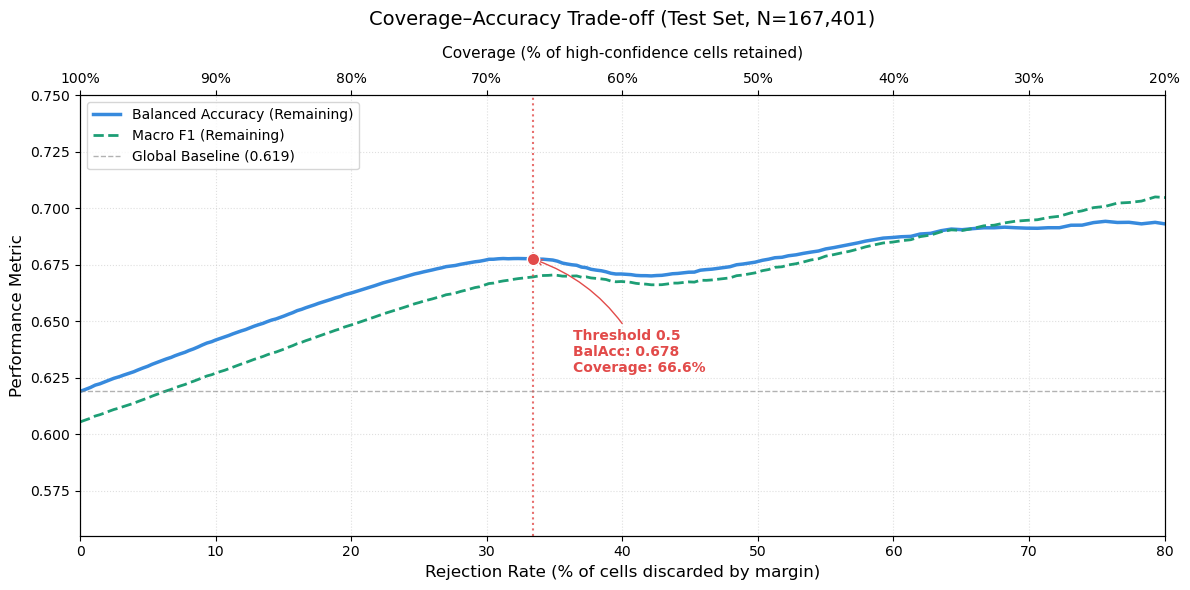

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# ── Config ──────────────────────────────────────────────────────────────
PRED_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3/predictions.parquet"
THRESHOLD = 0.5
N_STEPS   = 200
# ────────────────────────────────────────────────────────────────────────

df = pd.read_parquet(PRED_PATH)
all_fine_classes = sorted(df["label"].unique())
print(f"Loaded {len(df):,} cells  |  {df['label'].nunique()} fine classes")


def compute_metrics(y_true, y_pred, class_names):
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    true_idx = np.array([name_to_idx.get(y, -1) for y in y_true])
    pred_idx = np.array([name_to_idx.get(y, -1) for y in y_pred])
    rows = []
    for i, cname in enumerate(class_names):
        tp = int(((true_idx == i) & (pred_idx == i)).sum())
        fn = int(((true_idx == i) & (pred_idx != i)).sum())
        fp = int(((true_idx != i) & (pred_idx == i)).sum())
        n  = tp + fn
        if n == 0:
            continue
        prec = tp / max(tp + fp, 1)
        rec  = tp / max(tp + fn, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-12)
        rows.append({"class": cname, "n": n, "prec": prec, "rec": rec, "f1": f1})
    macro_f1 = float(np.mean([r["f1"] for r in rows]))
    bal_acc  = float(np.mean([r["rec"] for r in rows]))
    acc      = float((true_idx == pred_idx).sum()) / max(len(true_idx), 1)
    return rows, macro_f1, bal_acc, acc


# ── 1. Per-bucket table ───────────────────────────────────────────────────

buckets = [(0.0,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4),
           (0.4,0.5),(0.5,0.6),(0.6,0.7),(0.7,0.8),(0.8,0.9), (0.9, 1.0)]

print(f"\n{'═'*85}")
print(f"  {'Margin Bucket':<16} {'N':>8} {'Pop%':>10} {'BalAcc':>9} {'MacroF1':>10} {'Acc':>9}")
print(f"{'─'*85}")

bucket_records = []
for lo, hi in buckets:
    mask   = (df["router_margin"] >= lo) & (df["router_margin"] < hi)
    subset = df[mask]
    if len(subset) == 0:
        continue
    _, mf1, bal, acc = compute_metrics(
        subset["label"].values, subset["pred_top1"].values, all_fine_classes
    )
    cov = 100 * len(subset) / len(df)
    print(f"  [{lo:.1f}, {hi:.1f}) {len(subset):>12,} {cov:>9.1f}% {bal:>9.4f} {mf1:>10.4f} {acc:>9.4f}")
    bucket_records.append({"margin_lo": lo, "margin_hi": hi, "n": len(subset),
                            "coverage_pct": cov, "bal_acc": bal, "macro_f1": mf1, "acc": acc})

print(f"{'═'*85}")


# ── 2. Coverage-Accuracy curve computation ────────────────────────────────

margins  = df["router_margin"].values
y_true   = df["label"].values
y_pred   = df["pred_top1"].values

sort_idx  = np.argsort(margins)
margins_s = margins[sort_idx]
y_true_s  = y_true[sort_idx]
y_pred_s  = y_pred[sort_idx]

thresholds = np.linspace(margins_s[0], margins_s[-1] * 0.999, N_STEPS)
coverages, bal_accs, macro_f1s, ns = [], [], [], []

for t in thresholds:
    start = int(np.searchsorted(margins_s, t, side="left"))
    remaining = len(margins_s) - start
    if remaining < 50: # Avoid noise at very high thresholds
        break
    yt = y_true_s[start:]
    yp = y_pred_s[start:]
    _, mf1, bal, _ = compute_metrics(yt, yp, all_fine_classes)
    coverages.append(100 * remaining / len(df))
    bal_accs.append(bal)
    macro_f1s.append(mf1)

coverages = np.array(coverages)
rejection = 100 - coverages


# ── 3. High vs Low Confidence Summary (Threshold = 0.5) ───────────────────

high_mask = df["router_margin"] >= THRESHOLD
low_mask  = ~high_mask

print(f"\n{'═'*60}")
print(f"  STRATIFICATION SUMMARY (Threshold = {THRESHOLD})")
print(f"{'═'*60}")

for name, mask in [("HIGH Confidence", high_mask), ("LOW Confidence", low_mask)]:
    sub = df[mask]
    _, mf1, bal, acc = compute_metrics(sub["label"].values, sub["pred_top1"].values, all_fine_classes)
    pct = 100 * len(sub) / len(df)
    print(f"  {name:<16} | N={len(sub):<7,} ({pct:>4.1f}%) | BalAcc={bal:.4f} | Acc={acc:.4f}")

# ── 4. Plotting ───────────────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(12, 6))

color_bal = "#378ADD" # Blue
color_f1  = "#1D9E75" # Green
color_ref = "#E24B4A" # Red

ax1.plot(rejection, bal_accs,  color=color_bal, linewidth=2.5, label="Balanced Accuracy (Remaining)")
ax1.plot(rejection, macro_f1s, color=color_f1,  linewidth=2.0, linestyle="--", label="Macro F1 (Remaining)")

# Threshold Marker
ref_rej = 100 * (df["router_margin"] < THRESHOLD).mean()
high_df = df[df["router_margin"] >= THRESHOLD]
_, _, ref_bal, _ = compute_metrics(high_df["label"].values, high_df["pred_top1"].values, all_fine_classes)

ax1.axvline(ref_rej, color=color_ref, linestyle=":", linewidth=1.5, alpha=0.8)
ax1.scatter([ref_rej], [ref_bal], color=color_ref, zorder=5, s=80, edgecolors='white')
ax1.annotate(f"Threshold {THRESHOLD}\nBalAcc: {ref_bal:.3f}\nCoverage: {100-ref_rej:.1f}%",
             xy=(ref_rej, ref_bal),
             xytext=(ref_rej + 3, ref_bal - 0.05),
             fontsize=10, fontweight='bold', color=color_ref,
             arrowprops=dict(arrowstyle="->", color=color_ref, connectionstyle="arc3,rad=.2"))

# Baseline (Whole test set)
_, _, base_bal, _ = compute_metrics(df["label"].values, df["pred_top1"].values, all_fine_classes)

ax1.axhline(base_bal, color="gray", linestyle="--", linewidth=1.0, alpha=0.6, label=f"Global Baseline ({base_bal:.3f})")

ax1.set_xlabel("Rejection Rate (% of cells discarded by margin)", fontsize=12)
ax1.set_ylabel("Performance Metric", fontsize=12)
ax1.set_xlim(0, 80) # Custom range to show meaningful part
ax1.set_ylim(min(min(bal_accs), base_bal) - 0.05, 0.75)
ax1.legend(fontsize=10, loc="upper left", frameon=True)
ax1.set_title(f"Coverage–Accuracy Trade-off (Test Set, N={len(df):,})", fontsize=14, pad=15)
ax1.grid(True, which='both', linestyle=':', alpha=0.4)

# Top Axis for Coverage
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
tick_rej = np.linspace(0, 80, 9)
ax2.set_xticks(tick_rej)
ax2.set_xticklabels([f"{100-r:.0f}%" for r in tick_rej])
ax2.set_xlabel("Coverage (% of high-confidence cells retained)", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

Loaded 167,401 cells  |  21 fine classes

────────────────────────────────────────────────────────────────────────
  Margin               N  Coverage%   BalAcc   MacroF1      Acc
────────────────────────────────────────────────────────────────────────
  [0.0, 0.1)      11,707       7.0%   0.3299    0.3205   0.3297
  [0.1, 0.2)      10,894       6.5%   0.3784    0.3558   0.3721
  [0.2, 0.3)      10,491       6.3%   0.4139    0.3933   0.4171
  [0.3, 0.4)      10,957       6.5%   0.4602    0.4316   0.4736
  [0.4, 0.5)      11,841       7.1%   0.5112    0.4890   0.5247
  [0.5, 0.6)      12,084       7.2%   0.5661    0.5321   0.5692
  [0.6, 0.7)      13,826       8.3%   0.5947    0.5688   0.6091
  [0.7, 0.8)      18,402      11.0%   0.6160    0.5962   0.6474
  [0.8, 0.9)      26,326      15.7%   0.6512    0.6401   0.6946
  [0.9, 1.0)      40,873      24.4%   0.6944    0.7010   0.7753
────────────────────────────────────────────────────────────────────────


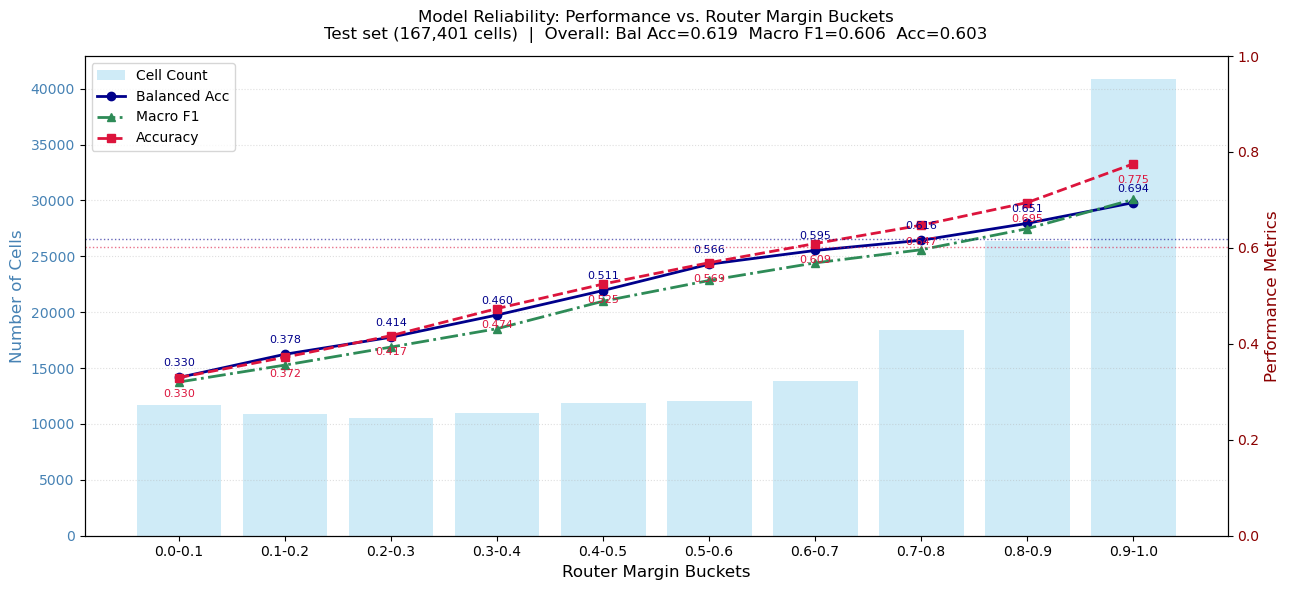

Saved: reliability_dual_axis.png


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRED_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3/predictions.parquet"

df = pd.read_parquet(PRED_PATH)
all_fine_classes = sorted(df["label"].unique())
print(f"Loaded {len(df):,} cells  |  {df['label'].nunique()} fine classes")


def compute_metrics(y_true, y_pred, class_names):
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    true_idx = np.array([name_to_idx.get(y, -1) for y in y_true])
    pred_idx = np.array([name_to_idx.get(y, -1) for y in y_pred])
    rows = []
    for i, cname in enumerate(class_names):
        tp = int(((true_idx == i) & (pred_idx == i)).sum())
        fn = int(((true_idx == i) & (pred_idx != i)).sum())
        fp = int(((true_idx != i) & (pred_idx == i)).sum())
        n  = tp + fn
        if n == 0:
            continue
        prec = tp / max(tp + fp, 1)
        rec  = tp / max(tp + fn, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-12)
        rows.append({"class": cname, "n": n, "prec": prec, "rec": rec, "f1": f1})
    macro_f1 = float(np.mean([r["f1"] for r in rows]))
    bal_acc  = float(np.mean([r["rec"] for r in rows]))
    acc      = float((true_idx == pred_idx).sum()) / max(len(true_idx), 1)
    return rows, macro_f1, bal_acc, acc


# ── Compute per-bucket metrics ────────────────────────────────────────────

buckets = [
    (0.0, 0.1), (0.1, 0.2), (0.2, 0.3), (0.3, 0.4),
    (0.4, 0.5), (0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9),(0.9, 1.0)
]

print(f"\n{'─'*72}")
print(f"  {'Margin':<14} {'N':>7} {'Coverage%':>10} {'BalAcc':>8} {'MacroF1':>9} {'Acc':>8}")
print(f"{'─'*72}")

bin_labels, cells, baccs, macros, accs = [], [], [], [], []

for lo, hi in buckets:
    mask   = (df["router_margin"] >= lo) & (df["router_margin"] < hi)
    subset = df[mask]
    if len(subset) == 0:
        continue
    _, mf1, bal, acc = compute_metrics(
        subset["label"].values, subset["pred_top1"].values, all_fine_classes
    )
    cov = 100 * len(subset) / len(df)
    print(f"  [{lo:.1f}, {hi:.1f})     {len(subset):>7,} {cov:>9.1f}% "
          f"{bal:>8.4f} {mf1:>9.4f} {acc:>8.4f}")

    bin_labels.append(f"{lo:.1f}-{hi:.1f}")
    cells.append(len(subset))
    baccs.append(bal)
    macros.append(mf1)
    accs.append(acc)

print(f"{'─'*72}")

# ── Plot ─────────────────────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

# Bar: cell count
bars = ax1.bar(bin_labels, cells, color="skyblue", alpha=0.4, label="Cell Count")

# Lines: performance
line1, = ax2.plot(bin_labels, baccs,  color="darkblue",  marker="o",
                  linewidth=2.0, label="Balanced Acc")
line2, = ax2.plot(bin_labels, macros, color="seagreen",  marker="^",
                  linewidth=2.0, linestyle="-.", label="Macro F1")
line3, = ax2.plot(bin_labels, accs,   color="crimson",   marker="s",
                  linewidth=2.0, linestyle="--", label="Accuracy")

# Value annotations
for i, (b, m, a) in enumerate(zip(baccs, macros, accs)):
    ax2.annotate(f"{b:.3f}", (bin_labels[i], b),
                 textcoords="offset points", xytext=(0, 8),
                 ha="center", fontsize=8, color="darkblue")
    ax2.annotate(f"{a:.3f}", (bin_labels[i], a),
                 textcoords="offset points", xytext=(0, -14),
                 ha="center", fontsize=8, color="crimson")

# Overall reference lines
_, overall_mf1, overall_bal, overall_acc = compute_metrics(
    df["label"].values, df["pred_top1"].values, all_fine_classes
)
ax2.axhline(overall_bal,  color="darkblue", linestyle=":", linewidth=1.0,
            alpha=0.6, label=f"Overall Bal Acc = {overall_bal:.3f}")
ax2.axhline(overall_acc,  color="crimson",  linestyle=":", linewidth=1.0,
            alpha=0.6, label=f"Overall Acc = {overall_acc:.3f}")

# Axes formatting
ax1.set_xlabel("Router Margin Buckets", fontsize=12)
ax1.set_ylabel("Number of Cells", fontsize=12, color="steelblue")
ax2.set_ylabel("Performance Metrics", fontsize=12, color="darkred")
ax2.set_ylim(0, 1.0)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="darkred")

# Combined legend
all_handles = [bars, line1, line2, line3]
all_labels  = ["Cell Count", "Balanced Acc", "Macro F1", "Accuracy"]
ax1.legend(all_handles, all_labels, loc="upper left", fontsize=10)

plt.title("Model Reliability: Performance vs. Router Margin Buckets\n"
          f"Test set ({len(df):,} cells)  |  "
          f"Overall: Bal Acc={overall_bal:.3f}  Macro F1={overall_mf1:.3f}  Acc={overall_acc:.3f}",
          fontsize=12, pad=12)
ax1.grid(axis="y", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("reliability_dual_axis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: reliability_dual_axis.png")

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Config ──────────────────────────────────────────────────────────────
PRED_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3/predictions.parquet"

FINE_TO_COARSE = {
    "Colon cancer cells": "Cancer", "Liver cancer cells": "Cancer",
    "Lung cancer cells": "Cancer", "Ovary cancer cells": "Cancer",
    "Pancreas cancer cells": "Cancer", "Skin cancer cells": "Cancer",
    "B cells": "Lymphoid", "NK cells": "Lymphoid", "T cells": "Lymphoid",
    "Astrocytes": "Neuroglial", "Microglia": "Neuroglial",
    "Neurons": "Neuroglial", "Oligodendrocytes": "Neuroglial",
    "Endothelial cells": "Tissue_Vascular", "Epithelial cells": "Tissue_Vascular",
    "Fibroblasts": "Tissue_Vascular", "Myeloid cells": "Tissue_Vascular",
    "Pericytes": "Tissue_Vascular", "Smooth muscle cells": "Tissue_Vascular",
    "Stem and progenitor cells": "Stem_Progenitor",
    "Stromal cells": "Stromal",
}

COARSE_ORDER = ["Cancer", "Lymphoid", "Neuroglial",
                "Stem_Progenitor", "Stromal", "Tissue_Vascular"]

COARSE_COLORS = {
    "Cancer": "#E24B4A", "Lymphoid": "#378ADD", "Neuroglial": "#1D9E75",
    "Tissue_Vascular": "#EF9F27", "Stem_Progenitor": "#7F77DD", "Stromal": "#888780",
}

# Hardcoded from eval log
ORACLE_F1 = {
    "Stem and progenitor cells": 1.000, "Stromal cells": 1.000,
    "Colon cancer cells": 1.000, "Pancreas cancer cells": 1.000,
    "Liver cancer cells": 0.999, "Skin cancer cells": 0.999,
    "Ovary cancer cells": 0.996, "Lung cancer cells": 0.996,
    "Oligodendrocytes": 0.832, "Neurons": 0.780,
    "Epithelial cells": 0.643, "T cells": 0.621,
    "B cells": 0.621, "NK cells": 0.615,
    "Microglia": 0.576, "Pericytes": 0.544,
    "Astrocytes": 0.533, "Endothelial cells": 0.511,
    "Myeloid cells": 0.497, "Smooth muscle cells": 0.476,
    "Fibroblasts": 0.443,
}

TOP1_F1 = {
    "Skin cancer cells": 0.934, "Liver cancer cells": 0.889,
    "Pancreas cancer cells": 0.872, "Colon cancer cells": 0.849,
    "Ovary cancer cells": 0.823, "Oligodendrocytes": 0.817,
    "Stem and progenitor cells": 0.769, "Neurons": 0.766,
    "Lung cancer cells": 0.756, "Stromal cells": 0.637,
    "NK cells": 0.510, "Microglia": 0.504,
    "Astrocytes": 0.490, "Pericytes": 0.486,
    "B cells": 0.434, "Epithelial cells": 0.421,
    "Endothelial cells": 0.389, "Fibroblasts": 0.375,
    "Smooth muscle cells": 0.363, "T cells": 0.335,
    "Myeloid cells": 0.297,
}

ORACLE_REC = {
    "Stem and progenitor cells": 1.000, "Stromal cells": 1.000,
    "Colon cancer cells": 1.000, "Pancreas cancer cells": 1.000,
    "Liver cancer cells": 0.999, "Skin cancer cells": 0.999,
    "Ovary cancer cells": 0.993, "Lung cancer cells": 0.999,
    "Oligodendrocytes": 0.823, "Neurons": 0.791,
    "Epithelial cells": 0.687, "T cells": 0.764,
    "B cells": 0.592, "NK cells": 0.502,
    "Microglia": 0.591, "Pericytes": 0.488,
    "Astrocytes": 0.532, "Endothelial cells": 0.507,
    "Myeloid cells": 0.464, "Smooth muscle cells": 0.465,
    "Fibroblasts": 0.474,
}

TOP1_REC = {
    "Skin cancer cells": 0.943, "Liver cancer cells": 0.972,
    "Pancreas cancer cells": 0.924, "Colon cancer cells": 0.854,
    "Ovary cancer cells": 0.857, "Oligodendrocytes": 0.822,
    "Stem and progenitor cells": 0.795, "Neurons": 0.790,
    "Lung cancer cells": 0.773, "Stromal cells": 0.760,
    "NK cells": 0.451, "Microglia": 0.557,
    "Astrocytes": 0.522, "Pericytes": 0.425,
    "B cells": 0.420, "Epithelial cells": 0.424,
    "Endothelial cells": 0.355, "Fibroblasts": 0.378,
    "Smooth muscle cells": 0.331, "T cells": 0.408,
    "Myeloid cells": 0.241,
}
# ────────────────────────────────────────────────────────────────────────

df = pd.read_parquet(PRED_PATH)
all_fine_classes = sorted(df["label"].unique())
n_classes = len(all_fine_classes)
cls_to_idx = {c: i for i, c in enumerate(all_fine_classes)}
print(f"Loaded {len(df):,} cells  |  {n_classes} fine classes")


def compute_metrics(y_true, y_pred, class_names):
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    true_idx = np.array([name_to_idx.get(y, -1) for y in y_true])
    pred_idx = np.array([name_to_idx.get(y, -1) for y in y_pred])
    rows = []
    for i, cname in enumerate(class_names):
        tp = int(((true_idx == i) & (pred_idx == i)).sum())
        fn = int(((true_idx == i) & (pred_idx != i)).sum())
        fp = int(((true_idx != i) & (pred_idx == i)).sum())
        n  = tp + fn
        if n == 0:
            continue
        prec = tp / max(tp + fp, 1)
        rec  = tp / max(tp + fn, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-12)
        rows.append({"class": cname, "n": n,
                     "prec": round(prec, 4), "rec": round(rec, 4), "f1": round(f1, 4)})
    macro_f1 = float(np.mean([r["f1"] for r in rows]))
    bal_acc  = float(np.mean([r["rec"] for r in rows]))
    return rows, macro_f1, bal_acc



Loaded 167,401 cells  |  21 fine classes


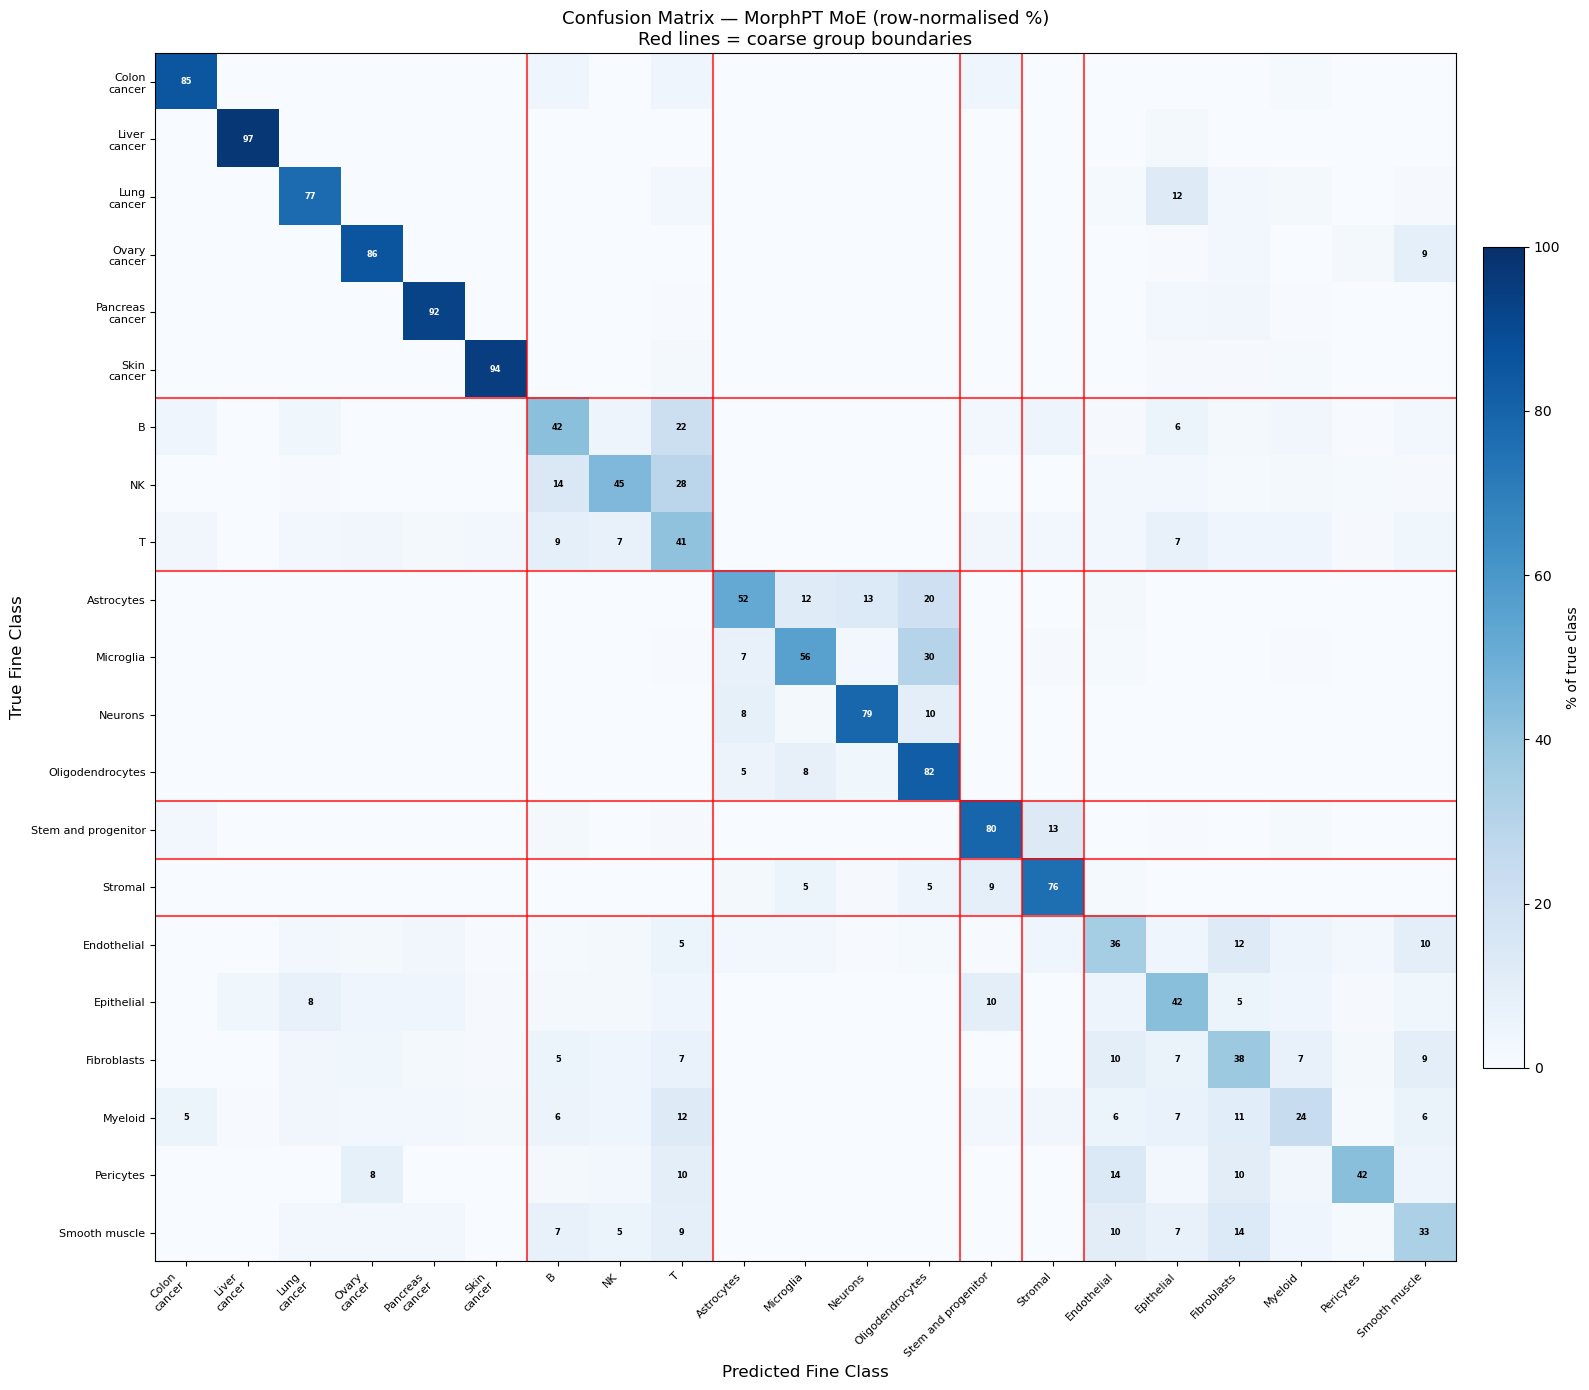

Saved: confusion_matrix_21x21.png


In [7]:

# ═══════════════════════════════════════════════════════════════
# 1. Confusion Matrix Heatmap (21×21, row-normalised %)
# ═══════════════════════════════════════════════════════════════

cm = np.zeros((n_classes, n_classes), dtype=np.int64)
for t, p in zip(df["label"].values, df["pred_top1"].values):
    ti, pi = cls_to_idx.get(t, -1), cls_to_idx.get(p, -1)
    if ti >= 0 and pi >= 0:
        cm[ti, pi] += 1

cm_pct = 100 * cm / cm.sum(axis=1, keepdims=True).clip(min=1)

# Sort by coarse group
sorted_classes = []
for coarse in COARSE_ORDER:
    sorted_classes += sorted([c for c in all_fine_classes
                               if FINE_TO_COARSE.get(c) == coarse])

sort_idx   = [cls_to_idx[c] for c in sorted_classes]
cm_sorted  = cm_pct[np.ix_(sort_idx, sort_idx)]

# Coarse group boundaries
boundaries = []
pos = 0
for coarse in COARSE_ORDER:
    pos += sum(1 for c in all_fine_classes if FINE_TO_COARSE.get(c) == coarse)
    boundaries.append(pos)

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm_sorted, cmap="Blues", vmin=0, vmax=100, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="% of true class")

short_labels = [c.replace(" cells", "").replace(" cancer", "\ncancer")
                for c in sorted_classes]
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(short_labels, fontsize=8)

for i in range(n_classes):
    for j in range(n_classes):
        val = cm_sorted[i, j]
        if val > 5:
            color = "white" if val > 60 else "black"
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                    fontsize=6, color=color, fontweight="bold")

for b in boundaries[:-1]:
    ax.axhline(b - 0.5, color="red", linewidth=1.5, alpha=0.7)
    ax.axvline(b - 0.5, color="red", linewidth=1.5, alpha=0.7)

ax.set_xlabel("Predicted Fine Class", fontsize=12)
ax.set_ylabel("True Fine Class", fontsize=12)
ax.set_title("Confusion Matrix — MorphPT MoE (row-normalised %)\n"
             "Red lines = coarse group boundaries", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix_21x21.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_21x21.png")



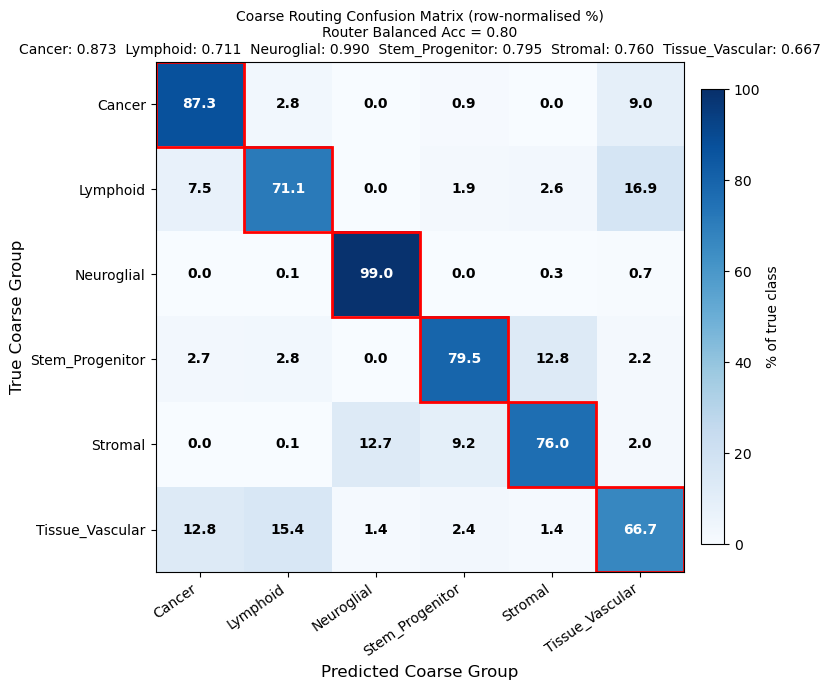

Saved: confusion_matrix_coarse_6x6.png


: 

In [ ]:
# ═══════════════════════════════════════════════════════════════
# 2. Coarse Confusion Matrix (6×6)
# ═══════════════════════════════════════════════════════════════

all_coarse_classes = COARSE_ORDER
n_coarse = len(all_coarse_classes)
coarse_to_idx = {c: i for i, c in enumerate(all_coarse_classes)}

cm_coarse = np.zeros((n_coarse, n_coarse), dtype=np.int64)
for t, p in zip(df["coarse_label"].values, df["router_pred"].values):
    ti, pi = coarse_to_idx.get(t, -1), coarse_to_idx.get(p, -1)
    if ti >= 0 and pi >= 0:
        cm_coarse[ti, pi] += 1

cm_coarse_pct = 100 * cm_coarse / cm_coarse.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm_coarse_pct, cmap="Blues", vmin=0, vmax=100, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label="% of true class")

ax.set_xticks(range(n_coarse))
ax.set_yticks(range(n_coarse))
ax.set_xticklabels(all_coarse_classes, rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(all_coarse_classes, fontsize=10)

# Annotate all cells
for i in range(n_coarse):
    for j in range(n_coarse):
        val = cm_coarse_pct[i, j]
        color = "white" if val > 60 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=10, color=color, fontweight="bold")

# Diagonal border
for k in range(n_coarse):
    ax.add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                                fill=False, edgecolor="red",
                                linewidth=2.0))

ax.set_xlabel("Predicted Coarse Group", fontsize=12)
ax.set_ylabel("True Coarse Group", fontsize=12)

# Per-class route acc from log
route_acc = {
    "Cancer": 0.8734, "Lymphoid": 0.7112, "Neuroglial": 0.9896,
    "Stem_Progenitor": 0.7952, "Stromal": 0.7597, "Tissue_Vascular": 0.6667,
}
overall_bal = 0.80
title_lines = "  ".join([f"{c}: {route_acc[c]:.3f}" for c in all_coarse_classes])
ax.set_title(f"Coarse Routing Confusion Matrix (row-normalised %)\n"
             f"Router Balanced Acc = {overall_bal:.2f}\n"
             f"{title_lines}",
             fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrix_coarse_6x6.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix_coarse_6x6.png")


Coarse Group Summary
Overall  →  Macro F1=0.6055  Bal Acc=0.6191
Coarse                Classes    Cells   Macro F1    Bal Acc
─────────────────────────────────────────────────────────────────
  Cancer                    6   50,782     0.9385     0.8869
  Lymphoid                  3   30,000     0.5032     0.4264
  Neuroglial                4   17,926     0.6737     0.6726
  Stem_Progenitor           1   10,000     0.8859     0.7952
  Stromal                   1    4,573     0.8634     0.7597
  Tissue_Vascular           6   54,120     0.4303     0.3591
─────────────────────────────────────────────────────────────────
  OVERALL                  21  167,401     0.6055     0.6191


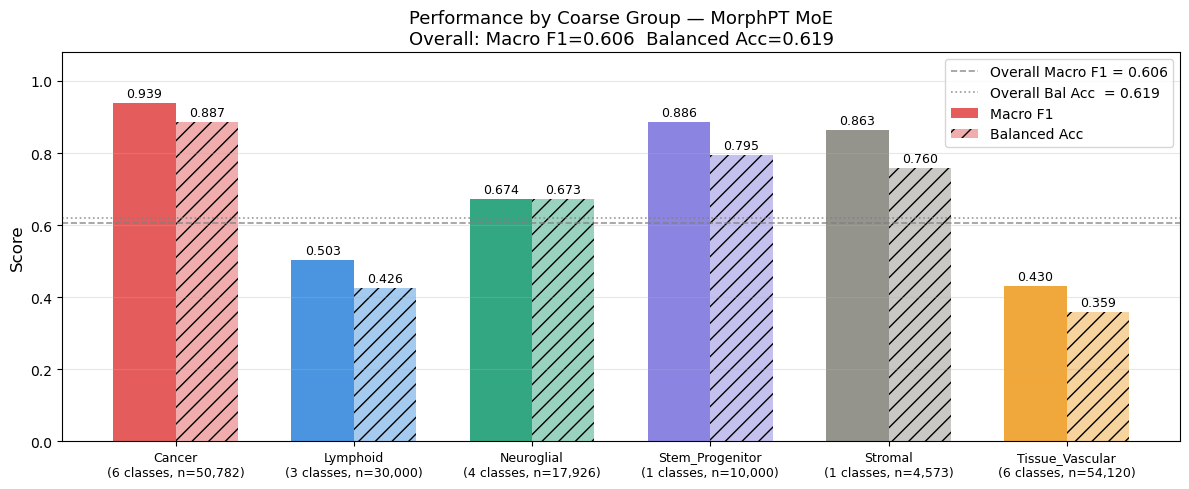

Saved: coarse_group_summary.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 3. Coarse Group F1 + Balanced Acc Summary
# ═══════════════════════════════════════════════════════════════

coarse_rows = []
for coarse in COARSE_ORDER:
    fines = [c for c in all_fine_classes if FINE_TO_COARSE.get(c) == coarse]
    mask  = df["label"].isin(fines)
    sub   = df[mask]
    rows, mf1, bal = compute_metrics(
        sub["label"].values, sub["pred_top1"].values, fines
    )
    coarse_rows.append({
        "coarse":    coarse,
        "n_classes": len(fines),
        "n_cells":   len(sub),
        "macro_f1":  round(mf1, 4),
        "bal_acc":   round(bal, 4),
    })

df_coarse = pd.DataFrame(coarse_rows)

# Print table
overall_mf1 = 0.6055
overall_bal = 0.6191

print("\n" + "="*65)
print(f"Coarse Group Summary")
print(f"Overall  →  Macro F1={overall_mf1:.4f}  Bal Acc={overall_bal:.4f}")
print("="*65)
print(f"{'Coarse':<20} {'Classes':>8} {'Cells':>8} {'Macro F1':>10} {'Bal Acc':>10}")
print("─"*65)
for _, r in df_coarse.iterrows():
    print(f"  {r['coarse']:<18} {r['n_classes']:>8} {r['n_cells']:>8,} "
          f"{r['macro_f1']:>10.4f} {r['bal_acc']:>10.4f}")
print("─"*65)
print(f"  {'OVERALL':<18} {'21':>8} {len(df):>8,} "
      f"{overall_mf1:>10.4f} {overall_bal:>10.4f}")

# Plot: grouped bar, F1 and Bal Acc side by side per coarse group
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(COARSE_ORDER))
width = 0.35

bars1 = ax.bar(x - width/2, df_coarse["macro_f1"], width,
               color=[COARSE_COLORS[c] for c in COARSE_ORDER],
               alpha=0.9, label="Macro F1")
bars2 = ax.bar(x + width/2, df_coarse["bal_acc"], width,
               color=[COARSE_COLORS[c] for c in COARSE_ORDER],
               alpha=0.45, label="Balanced Acc", hatch="//")

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

# Overall reference lines
ax.axhline(overall_mf1, color="gray", linestyle="--", linewidth=1.2, alpha=0.8,
           label=f"Overall Macro F1 = {overall_mf1:.3f}")
ax.axhline(overall_bal, color="gray", linestyle=":",  linewidth=1.2, alpha=0.8,
           label=f"Overall Bal Acc  = {overall_bal:.3f}")

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['coarse']}\n({r['n_classes']} classes, n={r['n_cells']:,})"
     for _, r in df_coarse.iterrows()],
    fontsize=9
)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Performance by Coarse Group — MorphPT MoE\n"
             f"Overall: Macro F1={overall_mf1:.3f}  Balanced Acc={overall_bal:.3f}",
             fontsize=13)
ax.legend(fontsize=10, loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("coarse_group_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: coarse_group_summary.png")




Oracle  →  Macro F1=0.7468  Bal Acc=0.7462
Top-1   →  Macro F1=0.6055  Bal Acc=0.6191
Class                               Coarse               O_F1   T_F1     ΔF1   O_Rec   T_Rec    ΔRec
──────────────────────────────────────────────────────────────────────────────────────────
  Stromal cells                     Stromal             1.000  0.637   0.363   1.000   0.760   0.240
  T cells                           Lymphoid            0.621  0.335   0.286   0.764   0.408   0.356
  Lung cancer cells                 Cancer              0.996  0.756   0.240   0.999   0.773   0.226
  Stem and progenitor cells         Stem_Progenitor     1.000  0.769   0.231   1.000   0.795   0.205
  Epithelial cells                  Tissue_Vascular     0.643  0.421   0.222   0.687   0.424   0.263
  Myeloid cells                     Tissue_Vascular     0.497  0.297   0.200   0.464   0.241   0.223
  B cells                           Lymphoid            0.621  0.434   0.187   0.592   0.420   0.172
  Ovary cancer

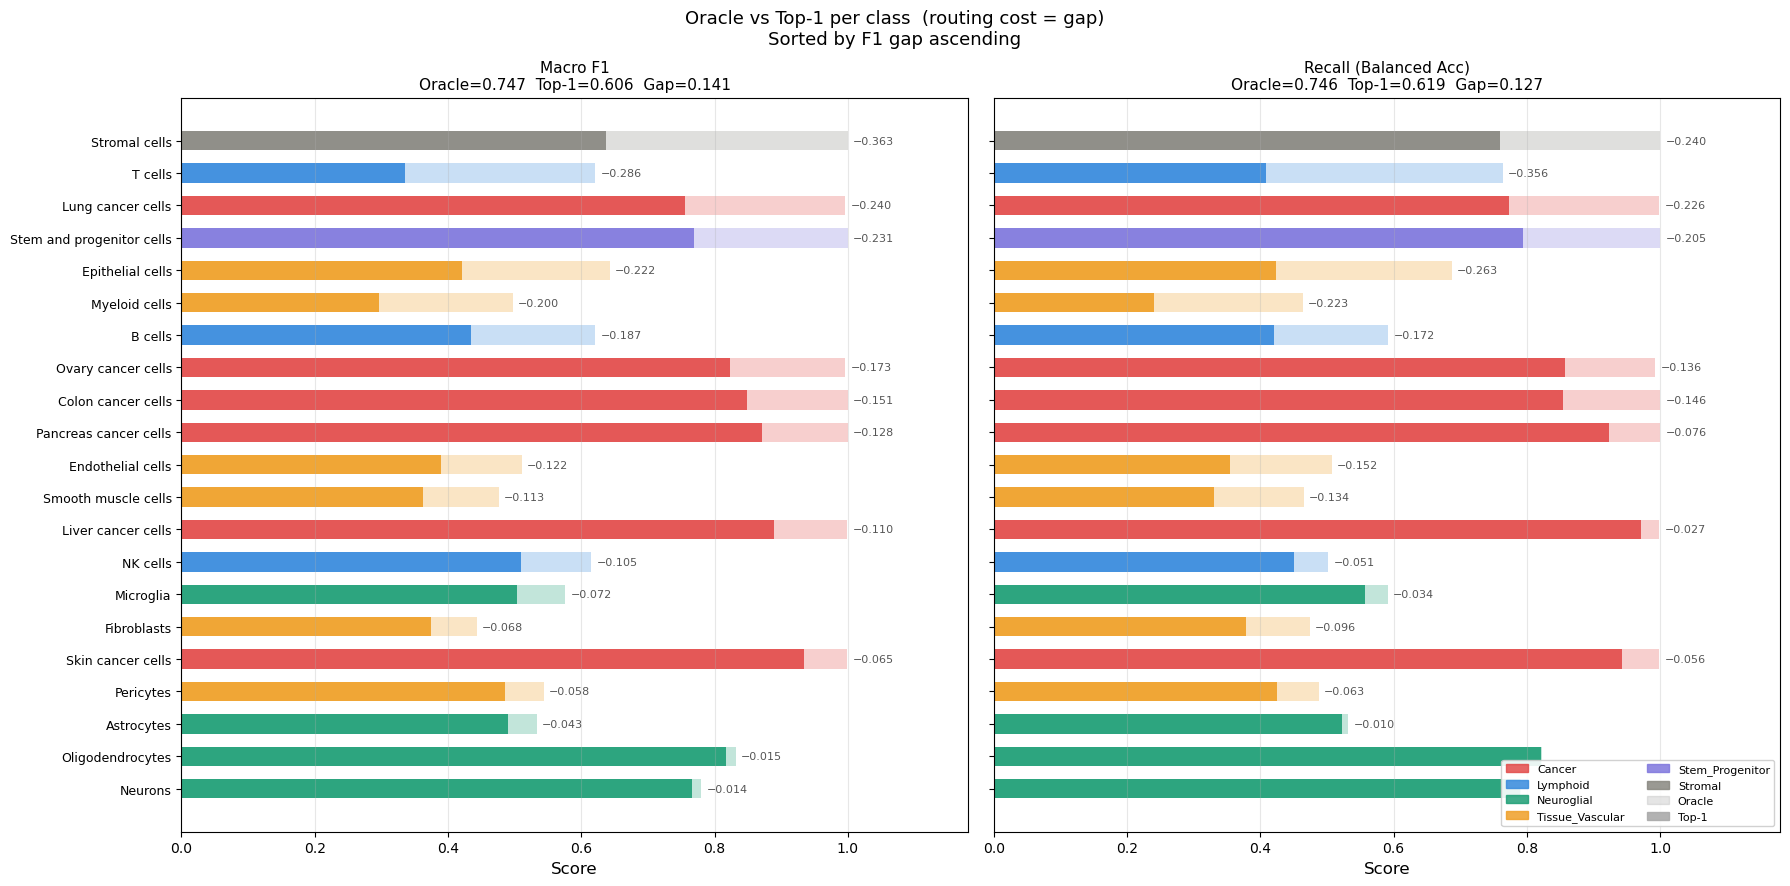

Saved: oracle_vs_top1_gap.png


In [ ]:

# ═══════════════════════════════════════════════════════════════
# 4. Oracle vs Top-1 Gap
# ═══════════════════════════════════════════════════════════════

gap_data = []
for cls in all_fine_classes:
    o_f1  = ORACLE_F1.get(cls, 0.0)
    t_f1  = TOP1_F1.get(cls, 0.0)
    o_rec = ORACLE_REC.get(cls, 0.0)
    t_rec = TOP1_REC.get(cls, 0.0)
    gap_data.append({
        "class":      cls,
        "coarse":     FINE_TO_COARSE.get(cls, "?"),
        "oracle_f1":  o_f1,  "top1_f1":  t_f1,  "gap_f1":  round(o_f1  - t_f1,  3),
        "oracle_rec": o_rec, "top1_rec": t_rec, "gap_rec": round(o_rec - t_rec, 3),
    })

df_gap = pd.DataFrame(gap_data).sort_values("gap_f1", ascending=True)

oracle_bal = round(np.mean(list(ORACLE_REC.values())), 4)
top1_bal   = round(np.mean(list(TOP1_REC.values())), 4)

# Print table
print("\n" + "="*90)
print(f"Oracle  →  Macro F1={np.mean(list(ORACLE_F1.values())):.4f}  Bal Acc={oracle_bal:.4f}")
print(f"Top-1   →  Macro F1={np.mean(list(TOP1_F1.values())):.4f}  Bal Acc={top1_bal:.4f}")
print("="*90)
print(f"{'Class':<35} {'Coarse':<18} {'O_F1':>6} {'T_F1':>6} {'ΔF1':>7} "
      f"{'O_Rec':>7} {'T_Rec':>7} {'ΔRec':>7}")
print("─"*90)
for _, r in df_gap.sort_values("gap_f1", ascending=False).iterrows():
    print(f"  {r['class']:<33} {r['coarse']:<18} "
          f"{r['oracle_f1']:>6.3f} {r['top1_f1']:>6.3f} {r['gap_f1']:>7.3f} "
          f"{r['oracle_rec']:>7.3f} {r['top1_rec']:>7.3f} {r['gap_rec']:>7.3f}")

# Plot: two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9), sharey=True)
y      = np.arange(len(df_gap))
colors = [COARSE_COLORS.get(c, "#888780") for c in df_gap["coarse"]]

for ax, oracle_col, top1_col, gap_col, title, overall_o, overall_t in [
    (ax1, "oracle_f1",  "top1_f1",  "gap_f1",
     f"Macro F1\nOracle={np.mean(list(ORACLE_F1.values())):.3f}  "
     f"Top-1={np.mean(list(TOP1_F1.values())):.3f}  "
     f"Gap={np.mean(list(ORACLE_F1.values()))-np.mean(list(TOP1_F1.values())):.3f}",
     None, None),
    (ax2, "oracle_rec", "top1_rec", "gap_rec",
     f"Recall (Balanced Acc)\nOracle={oracle_bal:.3f}  "
     f"Top-1={top1_bal:.3f}  Gap={oracle_bal-top1_bal:.3f}",
     None, None),
]:
    ax.barh(y, df_gap[oracle_col], height=0.6,
            color=[c + "44" for c in colors], edgecolor="none", label="Oracle")
    ax.barh(y, df_gap[top1_col], height=0.6,
            color=colors, alpha=0.9, label="Top-1")

    for i, (_, r) in enumerate(df_gap.iterrows()):
        if r[gap_col] > 0.001:
            ax.text(r[oracle_col] + 0.008, i,
                    f"−{r[gap_col]:.3f}", va="center", fontsize=8, color="#555555")

    ax.set_xlabel("Score", fontsize=12)
    ax.set_xlim(0, 1.18)
    ax.set_title(title, fontsize=11)
    ax.grid(axis="x", alpha=0.3)

ax1.set_yticks(y)
ax1.set_yticklabels(df_gap["class"], fontsize=9)

# Legend
coarse_handles = [plt.Rectangle((0,0), 1, 1, color=c, alpha=0.85)
                  for c in COARSE_COLORS.values()]
bar_handles = [
    plt.Rectangle((0,0), 1, 1, color="#aaaaaa", alpha=0.3),
    plt.Rectangle((0,0), 1, 1, color="#aaaaaa", alpha=0.9),
]
ax2.legend(coarse_handles + bar_handles,
           list(COARSE_COLORS.keys()) + ["Oracle", "Top-1"],
           fontsize=8, loc="lower right", ncol=2, framealpha=0.9)

fig.suptitle("Oracle vs Top-1 per class  (routing cost = gap)\n"
             "Sorted by F1 gap ascending", fontsize=13)
plt.tight_layout()
plt.savefig("oracle_vs_top1_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: oracle_vs_top1_gap.png")

Loading results...
  Loaded ResNet-50: 21 classes
  Loaded Swin-B: 21 classes
  Loaded DINOv2 ViT-B: 21 classes
  Loaded MorphPT MoE: 21 classes

Overall (all 21 classes):
  Model                       Macro F1    Bal Acc        Acc
  ─────────────────────────────────────────────────────────
  ResNet-50                     0.5775     0.5975     0.5863
  Swin-B                        0.5249     0.5644     0.5570
  DINOv2 ViT-B                  0.5393     0.5767     0.5721
  MorphPT MoE                   0.6055     0.6191     0.6026

Overall (15 classes, excl. Cancer):
  Model                       Macro F1    Bal Acc        Acc
  ─────────────────────────────────────────────────────────
  ResNet-50                     0.4769     0.4812     0.4562
  Swin-B                        0.4125     0.4270     0.4048
  DINOv2 ViT-B                  0.4263     0.4370     0.4193
  MorphPT MoE                   0.5062     0.5119     0.4849


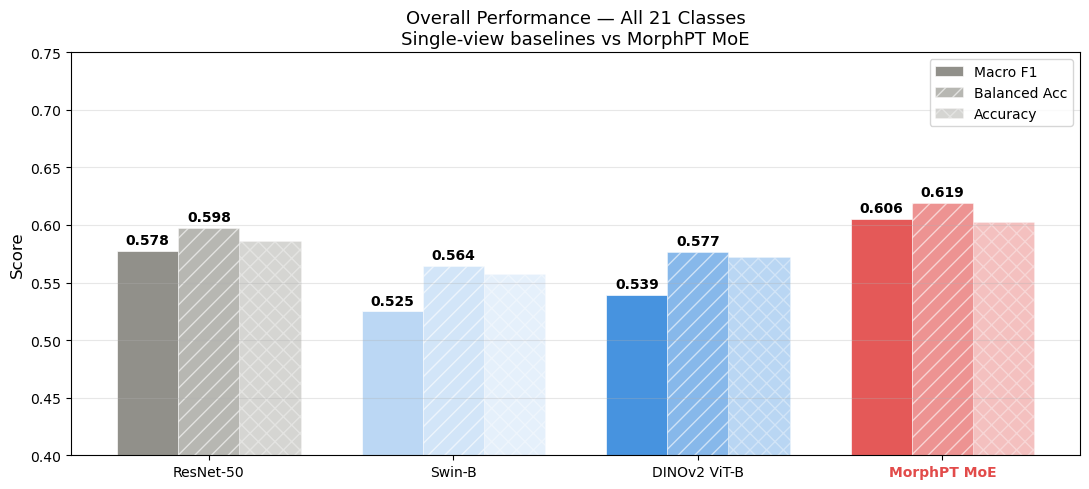


Saved: fig1_overall.png


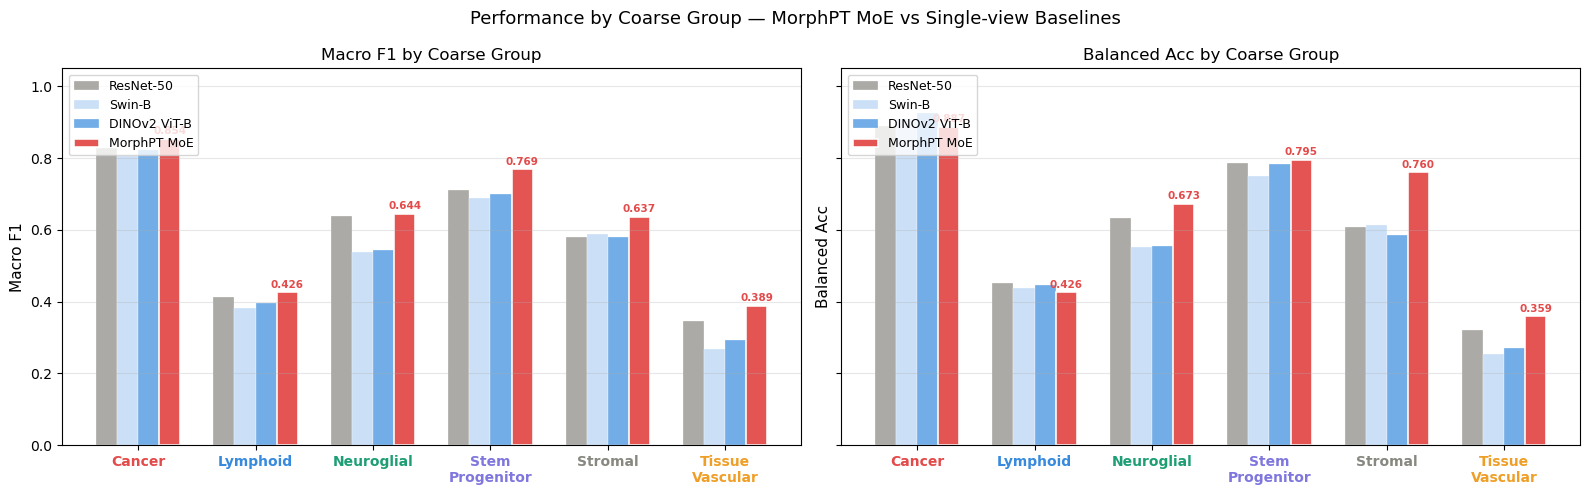

Saved: fig2_coarse_comparison.png


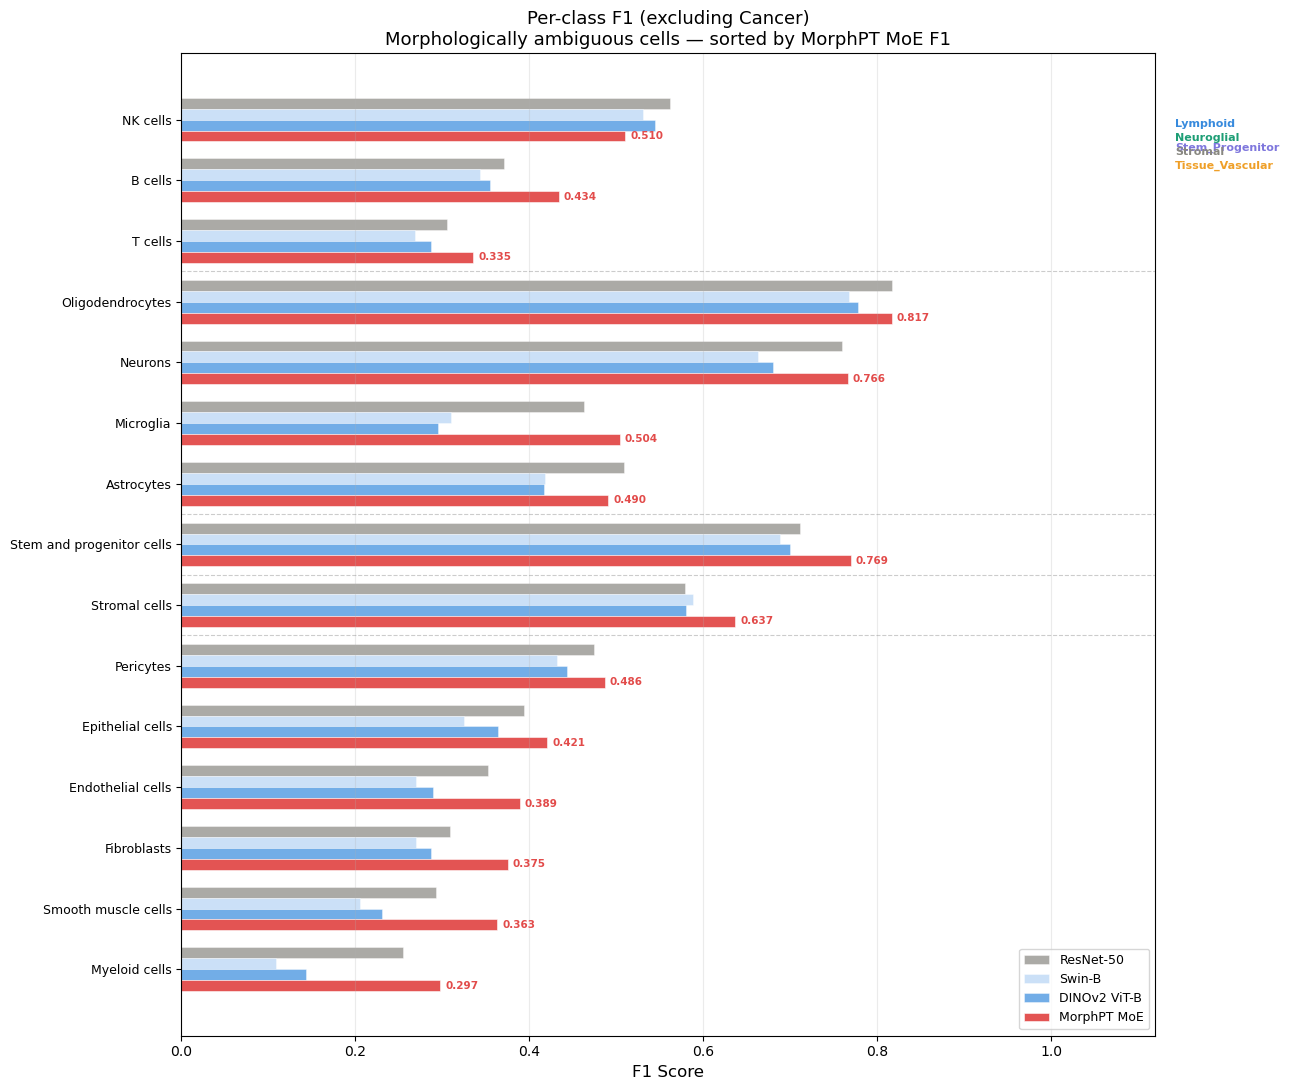

Saved: fig3_per_class_f1_no_cancer.png


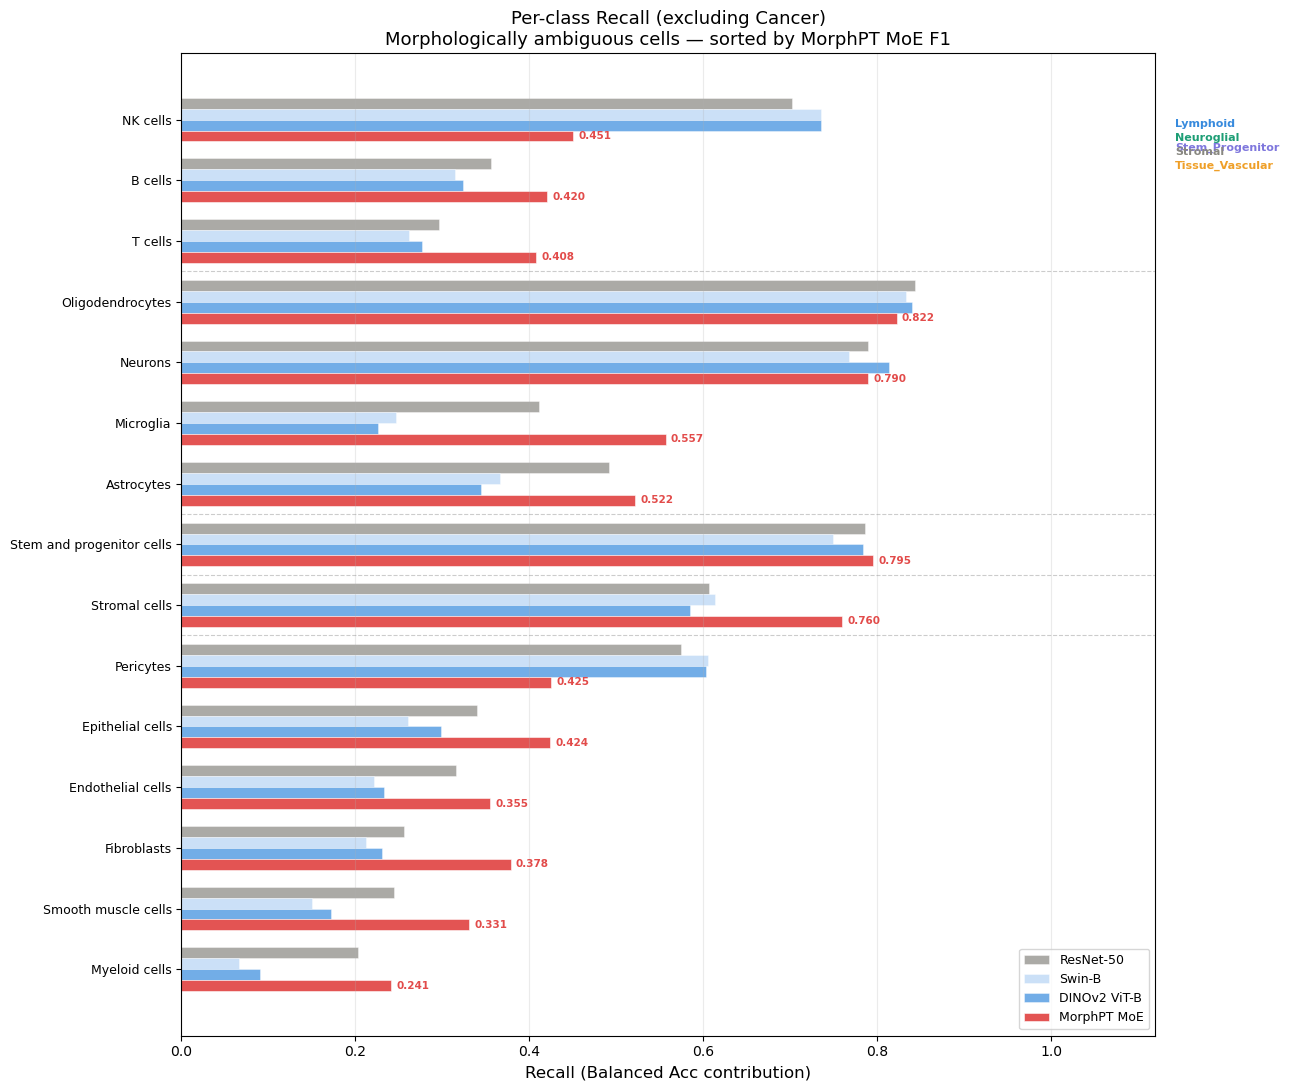

Saved: fig4_per_class_recall_no_cancer.png

Per-class comparison (excl. Cancer)
  Class                             Coarse               ResNet     Swin   DINOv2      MoE      ΔF1
  ───────────────────────────────────────────────────────────────────────────────────
  NK cells                          Lymphoid              0.562    0.531    0.544    0.510   -0.051 ↓
  B cells                           Lymphoid              0.371    0.344    0.355    0.434   +0.063 ↑
  T cells                           Lymphoid              0.305    0.269    0.287    0.335   +0.030 ↑
  ───────────────────────────────────────────────────────────────────────────────────
  Oligodendrocytes                  Neuroglial            0.817    0.768    0.778    0.817   -0.001  
  Neurons                           Neuroglial            0.760    0.663    0.680    0.766   +0.006  
  Microglia                         Neuroglial            0.463    0.309    0.295    0.504   +0.041 ↑
  Astrocytes                        

In [ ]:
#!/usr/bin/env python3
"""
Baseline vs MorphPT MoE comparison
====================================
Reads per_class.json from each experiment directory and generates:
  1. Overall score comparison (Macro F1 + Bal Acc)
  2. Per-coarse-group F1 + Bal Acc grouped bar chart
  3. Per-class F1 (excluding Cancer) grouped bar chart
  4. Per-class Recall (excluding Cancer)
  5. Delta plot: MoE vs best baseline (excluding Cancer)

Usage: python scripts/compare_baselines.py
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────
BASE       = Path("/hpc/group/jilab/rz179/MorphPT_MOE/experiments")
MOE_RESULT = Path("/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3")

MODEL_PATHS = {
    "ResNet-50_full\n(2.5×)":        BASE / "baseline_resnet50_2p5x" / "per_class.json",
    "ResNet-50_full\n(10.x)":        BASE / "baseline_resnet50_10x" / "per_class.json",
    "ResNet-50_freeze\n(2.5×)":        BASE / "baseline_resnet50_freeze_2p5x" / "per_class.json",
    "ResNet-50_freeze\n(10.x)":        BASE / "baseline_resnet50_freeze_10x" / "per_class.json",
    "ConvNext\n(2.5×)":        BASE / "baseline_convnextv2_base.fcmae_ft_in22k_in1k_2p5x" / "per_class.json",
    "ConvNext\n(10.x)":        BASE / "baseline_convnextv2_base.fcmae_ft_in22k_in1k_10x" / "per_class.json",
    "Swin-B\n(2.5×)":           BASE / "baseline_swin_base_patch4_window7_224_2p5x" / "per_class.json",
    "Swin-B\n(10.×)":           BASE / "baseline_swin_base_patch4_window7_224_10x" / "per_class.json",
    "DINOv3 ViT-B\n(2.5×)":    BASE / "baseline_vit_base_patch16_dinov3.lvd1689m_2p5x" / "per_class.json",
    "DINOv3 ViT-B\n(10.×)":    BASE / "baseline_vit_base_patch16_dinov3.lvd1689m_10x" / "per_class.json",
    "MorphPT MoE\n(2.5×+10×)": MOE_RESULT / "per_class_top1.json",
}

MODEL_COLORS = {
    "ResNet-50\n(2.5×)":        "#888780",
    "Swin-B\n(2.5×)":           "#B5D4F4",
    "DINOv2 ViT-B\n(2.5×)":    "#378ADD",
    "MorphPT MoE\n(2.5×+10×)": "#E24B4A",
}

MODEL_SHORT = {
    "ResNet-50\n(2.5×)":        "ResNet-50",
    "Swin-B\n(2.5×)":           "Swin-B",
    "DINOv2 ViT-B\n(2.5×)":    "DINOv2 ViT-B",
    "MorphPT MoE\n(2.5×+10×)": "MorphPT MoE",
}

FINE_TO_COARSE = {
    "Colon cancer cells":         "Cancer",
    "Liver cancer cells":         "Cancer",
    "Lung cancer cells":          "Cancer",
    "Ovary cancer cells":         "Cancer",
    "Pancreas cancer cells":      "Cancer",
    "Skin cancer cells":          "Cancer",
    "B cells":                    "Lymphoid",
    "NK cells":                   "Lymphoid",
    "T cells":                    "Lymphoid",
    "Astrocytes":                 "Neuroglial",
    "Microglia":                  "Neuroglial",
    "Neurons":                    "Neuroglial",
    "Oligodendrocytes":           "Neuroglial",
    "Endothelial cells":          "Tissue_Vascular",
    "Epithelial cells":           "Tissue_Vascular",
    "Fibroblasts":                "Tissue_Vascular",
    "Myeloid cells":              "Tissue_Vascular",
    "Pericytes":                  "Tissue_Vascular",
    "Smooth muscle cells":        "Tissue_Vascular",
    "Stem and progenitor cells":  "Stem_Progenitor",
    "Stromal cells":              "Stromal",
}

COARSE_ORDER = ["Cancer", "Lymphoid", "Neuroglial",
                "Stem_Progenitor", "Stromal", "Tissue_Vascular"]

COARSE_ORDER_NO_CANCER = ["Lymphoid", "Neuroglial",
                           "Stem_Progenitor", "Stromal", "Tissue_Vascular"]

COARSE_COLORS = {
    "Cancer":          "#E24B4A",
    "Lymphoid":        "#378ADD",
    "Neuroglial":      "#1D9E75",
    "Tissue_Vascular": "#EF9F27",
    "Stem_Progenitor": "#7F77DD",
    "Stromal":         "#888780",
}


# ── Load data ─────────────────────────────────────────────────────────────

def load_per_class(path):
    rows = json.loads(Path(path).read_text())
    return {r["class"]: r for r in rows}

print("Loading results...")
RESULTS_RAW = {}
for model, path in MODEL_PATHS.items():
    p = Path(path)
    if not p.exists():
        print(f"  WARNING: {p} not found — skipping {MODEL_SHORT[model]}")
        continue
    RESULTS_RAW[model] = load_per_class(p)
    print(f"  Loaded {MODEL_SHORT[model]}: {len(RESULTS_RAW[model])} classes")

models    = list(RESULTS_RAW.keys())
moe_key   = "MorphPT MoE\n(2.5×+10×)"
bl_models = [m for m in models if "MoE" not in m]
all_classes = sorted(RESULTS_RAW[models[0]].keys())


def get_metric(model, cls, metric):
    return RESULTS_RAW.get(model, {}).get(cls, {}).get(metric, 0.0)


# ── Sorted fine classes (all + non-cancer) ────────────────────────────────

def make_sorted_classes(coarse_list):
    out = []
    for coarse in coarse_list:
        fines = [c for c in all_classes if FINE_TO_COARSE.get(c) == coarse]
        fines_sorted = sorted(
            fines,
            key=lambda c: get_metric(moe_key, c, "f1"),
            reverse=True
        )
        out += fines_sorted
    return out

sorted_all        = make_sorted_classes(COARSE_ORDER)
#sorted_no_cancer  = make_sorted_classes(COARSE_ORDER_NO_CANCER)


# ── Overall scores ─────────────────────────────────────────────────────────

def compute_overall(class_list):
    result = {}
    for model, class_data in RESULTS_RAW.items():
        subset = [class_data[c] for c in class_list 
                  if c in class_data and class_data[c].get("n", 0) > 0]
        # 加权平均 acc = sum(tp) / sum(n)
        total_n  = sum(r["n"] for r in subset)
        total_tp = sum(round(r["rec"] * r["n"]) for r in subset)
        result[model] = {
            "macro_f1": round(float(np.mean([r["f1"]  for r in subset])), 4),
            "bal_acc":  round(float(np.mean([r["rec"] for r in subset])), 4),
            "acc":      round(total_tp / total_n, 4) if total_n > 0 else 0.0,
        }
    return result

OVERALL_ALL        = compute_overall(all_classes)
#OVERALL_NO_CANCER  = compute_overall(sorted_no_cancer)

print("\nOverall (all 21 classes):")
print(f"  {'Model':<25} {'Macro F1':>10} {'Bal Acc':>10} {'Acc':>10}")
print("  " + "─"*57)
for m in models:
    s = OVERALL_ALL[m]
    print(f"  {MODEL_SHORT[m]:<25} {s['macro_f1']:>10.4f} {s['bal_acc']:>10.4f} {s['acc']:>10.4f}")

print("\nOverall (15 classes, excl. Cancer):")
print(f"  {'Model':<25} {'Macro F1':>10} {'Bal Acc':>10} {'Acc':>10}")
print("  " + "─"*57)
for m in models:
    s = OVERALL_ALL[m]
    print(f"  {MODEL_SHORT[m]:<25} {s['macro_f1']:>10.4f} {s['bal_acc']:>10.4f} {s['acc']:>10.4f}")


# ── Per-coarse scores ──────────────────────────────────────────────────────

def coarse_scores(model, coarse, metric):
    fines = [c for c in all_classes
             if FINE_TO_COARSE.get(c) == coarse
             and get_metric(model, c, "n") > 0]
    vals = [get_metric(model, c, metric) for c in fines]
    return float(np.mean(vals)) if vals else 0.0

COARSE_F1  = {m: {c: round(coarse_scores(m, c, "f1"),  4) for c in COARSE_ORDER} for m in models}
COARSE_BAL = {m: {c: round(coarse_scores(m, c, "rec"), 4) for c in COARSE_ORDER} for m in models}


# ── Helper: separator lines ────────────────────────────────────────────────

def add_separators(ax, cls_list, coarse_list):
    pos = 0
    n   = len(cls_list)
    for coarse in coarse_list:
        count = sum(1 for c in cls_list if FINE_TO_COARSE.get(c) == coarse)
        mid   = pos + count / 2 - 0.5
        if pos > 0:
            ax.axhline(pos - 0.5, color="gray", linewidth=0.8,
                       linestyle="--", alpha=0.4)
        ax.text(1.02, mid / n, coarse,
                transform=ax.get_yaxis_transform(),
                fontsize=8, va="center",
                color=COARSE_COLORS.get(coarse, "gray"),
                fontweight="bold")
        pos += count


# ═══════════════════════════════════════════════════════════════
# Fig 1. Overall score comparison (all 21 classes)
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(models))
width = 0.25
y_min = 0.40

f1_vals  = [OVERALL_ALL[m]["macro_f1"] for m in models]
bal_vals = [OVERALL_ALL[m]["bal_acc"]  for m in models]
acc_vals = [OVERALL_ALL[m]["acc"]      for m in models]
colors   = [MODEL_COLORS[m] for m in models]

bars1 = ax.bar(x - width, f1_vals,  width, color=colors, alpha=0.92,
               label="Macro F1", edgecolor="white", linewidth=0.5)
bars2 = ax.bar(x,          bal_vals, width, color=colors, alpha=0.60,
               label="Balanced Acc", edgecolor="white", linewidth=0.5, hatch="//")
bars3 = ax.bar(x + width,  acc_vals, width, color=colors, alpha=0.35,
               label="Accuracy", edgecolor="white", linewidth=0.5, hatch="xx")

for bar, val in zip(list(bars1) + list(bars2), f1_vals + bal_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f"{val:.3f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

# Improvement annotation over best baseline
if moe_key in models and bl_models:
    best_f1  = max(OVERALL_ALL[m]["macro_f1"] for m in bl_models)
    best_bal = max(OVERALL_ALL[m]["bal_acc"]  for m in bl_models)
    mi = models.index(moe_key)
    mf = OVERALL_ALL[moe_key]["macro_f1"]
    mb = OVERALL_ALL[moe_key]["bal_acc"]

ax.set_xticks(x)
ax.set_xticklabels([MODEL_SHORT[m] for m in models], fontsize=10)
ax.set_ylim(y_min, 0.75)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Overall Performance — All 21 Classes\nSingle-view baselines vs MorphPT MoE",
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
if moe_key in models:
    ax.get_xticklabels()[models.index(moe_key)].set_fontweight("bold")
    ax.get_xticklabels()[models.index(moe_key)].set_color("#E24B4A")

plt.tight_layout()
plt.savefig("fig1_overall.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: fig1_overall.png")


# ═══════════════════════════════════════════════════════════════
# Fig 2. Per-coarse-group F1 and Bal Acc
# ═══════════════════════════════════════════════════════════════

fig, (ax_f1, ax_bal) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

n_coarse   = len(COARSE_ORDER)
xc         = np.arange(n_coarse)
cw         = 0.18
coarse_labels = [c.replace("_", "\n") for c in COARSE_ORDER]

for ax, score_dict, title, metric_label in [
    (ax_f1,  COARSE_F1,  "Macro F1 by Coarse Group",  "Macro F1"),
    (ax_bal, COARSE_BAL, "Balanced Acc by Coarse Group", "Balanced Acc"),
]:
    for mi, model in enumerate(models):
        offset = (mi - len(models)/2 + 0.5) * cw
        vals   = [score_dict[model][c] for c in COARSE_ORDER]
        lw     = 1.2 if model == moe_key else 0.3
        alpha  = 0.95 if model == moe_key else 0.70
        bars   = ax.bar(xc + offset, vals, cw,
                        color=MODEL_COLORS[model], alpha=alpha,
                        label=MODEL_SHORT[model],
                        edgecolor="white", linewidth=lw)
        if model == moe_key:
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.007,
                        f"{val:.3f}", ha="center", va="bottom",
                        fontsize=7.5, color="#E24B4A", fontweight="bold")

    ax.set_xticks(xc)
    ax.set_xticklabels(coarse_labels, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=9, loc="upper left")

    # Coarse group colors on x-axis labels
    for tick, coarse in zip(ax.get_xticklabels(), COARSE_ORDER):
        tick.set_color(COARSE_COLORS.get(coarse, "black"))
        tick.set_fontweight("bold")

fig.suptitle("Performance by Coarse Group — MorphPT MoE vs Single-view Baselines",
             fontsize=13)
plt.tight_layout()
plt.savefig("fig2_coarse_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_coarse_comparison.png")


# ═══════════════════════════════════════════════════════════════
# Fig 3. Per-class F1
# ═══════════════════════════════════════════════════════════════
nc   = len(sorted_no_cancer)
nm   = len(models)
h    = 0.18
y    = np.arange(nc)

fig, ax = plt.subplots(figsize=(13, 11))

for mi, model in enumerate(models):
    offset = (mi - nm/2 + 0.5) * h
    vals   = [get_metric(model, c, "f1") for c in sorted_no_cancer]
    alpha  = 0.95 if model == moe_key else 0.70
    ax.barh(y + offset, vals, height=h,
            color=MODEL_COLORS[model], alpha=alpha,
            label=MODEL_SHORT[model],
            edgecolor="white", linewidth=0.4)

# MoE annotations
if moe_key in RESULTS_RAW:
    for i, cls in enumerate(sorted_no_cancer):
        val = get_metric(moe_key, cls, "f1")
        ax.text(val + 0.006, i + (nm/2 - 0.5) * h,
                f"{val:.3f}", va="center", fontsize=7.5,
                color="#E24B4A", fontweight="bold")

add_separators(ax, sorted_no_cancer, COARSE_ORDER_NO_CANCER)

ax.set_yticks(y)
ax.set_yticklabels(sorted_no_cancer, fontsize=9)
ax.set_xlabel("F1 Score", fontsize=12)
ax.set_xlim(0, 1.12)
ax.set_title("Per-class F1\n"
             "Morphologically ambiguous cells — sorted by MorphPT MoE F1",
             fontsize=13)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()

# Overall non-cancer stats
if moe_key in models and bl_models:
    best = max(OVERALL_NO_CANCER[m]["macro_f1"] for m in bl_models)
    moe  = OVERALL_NO_CANCER[moe_key]["macro_f1"]

plt.tight_layout()
plt.savefig("fig3_per_class_f1_no_cancer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig3_per_class_f1_no_cancer.png")


# ═══════════════════════════════════════════════════════════════
# Fig 4. Per-class Recall — excluding Cancer
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, 11))

for mi, model in enumerate(models):
    offset = (mi - nm/2 + 0.5) * h
    vals   = [get_metric(model, c, "rec") for c in sorted_no_cancer]
    alpha  = 0.95 if model == moe_key else 0.70
    ax.barh(y + offset, vals, height=h,
            color=MODEL_COLORS[model], alpha=alpha,
            label=MODEL_SHORT[model],
            edgecolor="white", linewidth=0.4)

if moe_key in RESULTS_RAW:
    for i, cls in enumerate(sorted_no_cancer):
        val = get_metric(moe_key, cls, "rec")
        ax.text(val + 0.006, i + (nm/2 - 0.5) * h,
                f"{val:.3f}", va="center", fontsize=7.5,
                color="#E24B4A", fontweight="bold")

add_separators(ax, sorted_no_cancer, COARSE_ORDER_NO_CANCER)

ax.set_yticks(y)
ax.set_yticklabels(sorted_no_cancer, fontsize=9)
ax.set_xlabel("Recall (Balanced Acc contribution)", fontsize=12)
ax.set_xlim(0, 1.12)
ax.set_title("Per-class Recall (excluding Cancer)\n"
             "Morphologically ambiguous cells — sorted by MorphPT MoE F1",
             fontsize=13)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()

if moe_key in models and bl_models:
    best = max(OVERALL_NO_CANCER[m]["bal_acc"] for m in bl_models)
    moe  = OVERALL_NO_CANCER[moe_key]["bal_acc"]

plt.tight_layout()
plt.savefig("fig4_per_class_recall_no_cancer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_per_class_recall_no_cancer.png")




# ── Summary table ─────────────────────────────────────────────────────────

print("\n" + "="*85)
print("Per-class comparison (excl. Cancer)")
print("="*85)
print(f"  {'Class':<33} {'Coarse':<18}"
      f" {'ResNet':>8} {'Swin':>8} {'DINOv2':>8} {'MoE':>8} {'ΔF1':>8}")
print("  " + "─"*83)

prev_coarse = None
for cls in sorted_no_cancer:
    coarse = FINE_TO_COARSE.get(cls, "?")
    if coarse != prev_coarse:
        if prev_coarse is not None:
            print(f"  {'─'*83}")
        prev_coarse = coarse
    vals    = [get_metric(m, cls, "f1") for m in models]
    best_bl = max(vals[:-1])
    delta   = vals[-1] - best_bl
    flag    = " ↑" if delta > 0.01 else (" ↓" if delta < -0.01 else "  ")
    print(f"  {cls:<33} {coarse:<18}"
          f" {vals[0]:>8.3f} {vals[1]:>8.3f} {vals[2]:>8.3f} {vals[3]:>8.3f}"
          f" {delta:>+8.3f}{flag}")

print("\n" + "="*85)
print("Overall scores")
print("="*85)
print(f"  {'Model':<25} {'All 21 — F1':>12} {'All 21 — Bal':>13}"
      f" {'No Cancer — F1':>15} {'No Cancer — Bal':>16}")
print("  " + "─"*83)
for m in models:
    a = OVERALL_ALL[m]
    b = OVERALL_NO_CANCER[m]
    print(f"  {MODEL_SHORT[m]:<25} {a['macro_f1']:>12.4f} {a['bal_acc']:>13.4f}"
          f" {b['macro_f1']:>15.4f} {b['bal_acc']:>16.4f}")

print("\nDone.")

Mode: FULL (with supplementary)
Loading results...
  Loaded ResNet_full: 21 classes
  Loaded ResNet_lp: 21 classes
  Loaded ConvNext_lora: 21 classes
  Loaded Swin-B: 21 classes
  Loaded DINOv3: 21 classes
  Loaded MorphPT: 21 classes

Overall (all 21 classes):
  Model                       Macro F1    Bal Acc        Acc
  ─────────────────────────────────────────────────────────
  ResNet_full                   0.5775     0.5975     0.5863
  ResNet_lp                     0.3005     0.3231     0.3405
  ConvNext_lora                 0.5710     0.6012     0.5931
  Swin-B                        0.5249     0.5644     0.5570
  DINOv3                        0.5393     0.5767     0.5721
  MorphPT                       0.6055     0.6191     0.6026

Overall (15 classes, excl. Cancer):
  Model                       Macro F1    Bal Acc        Acc
  ─────────────────────────────────────────────────────────
  ResNet_full                   0.4769     0.4812     0.4562
  ResNet_lp                     

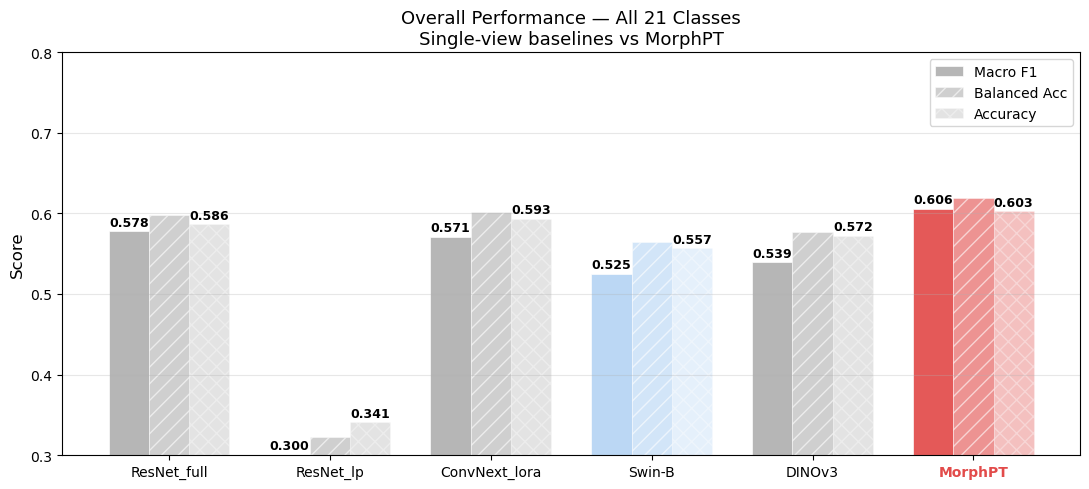

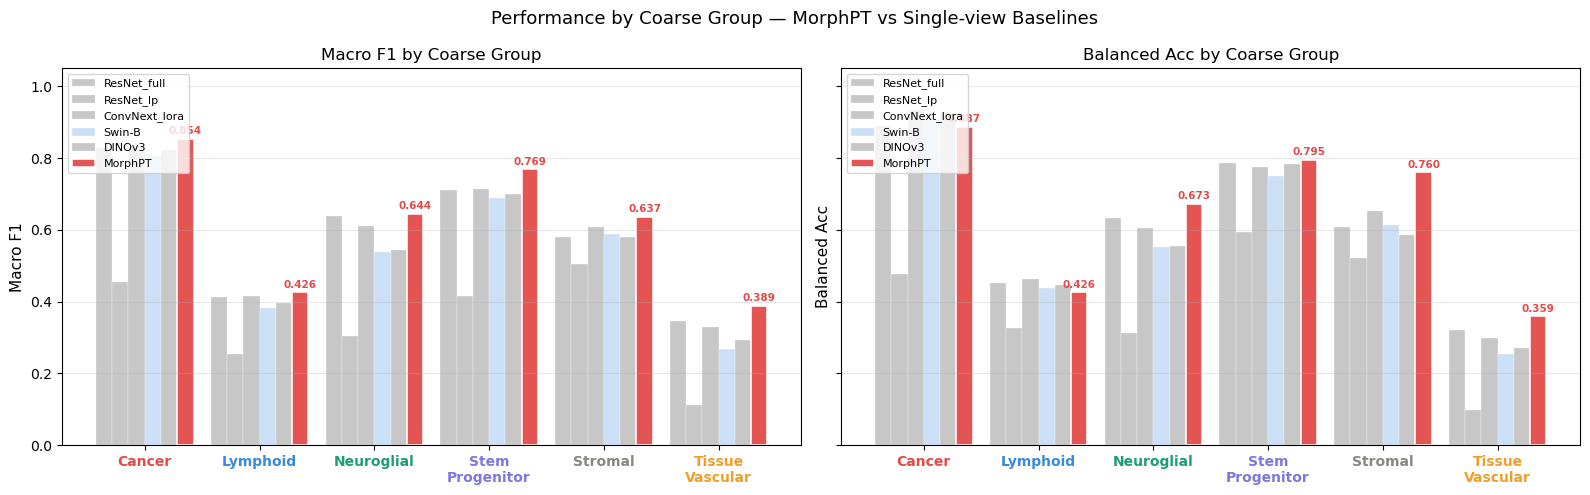

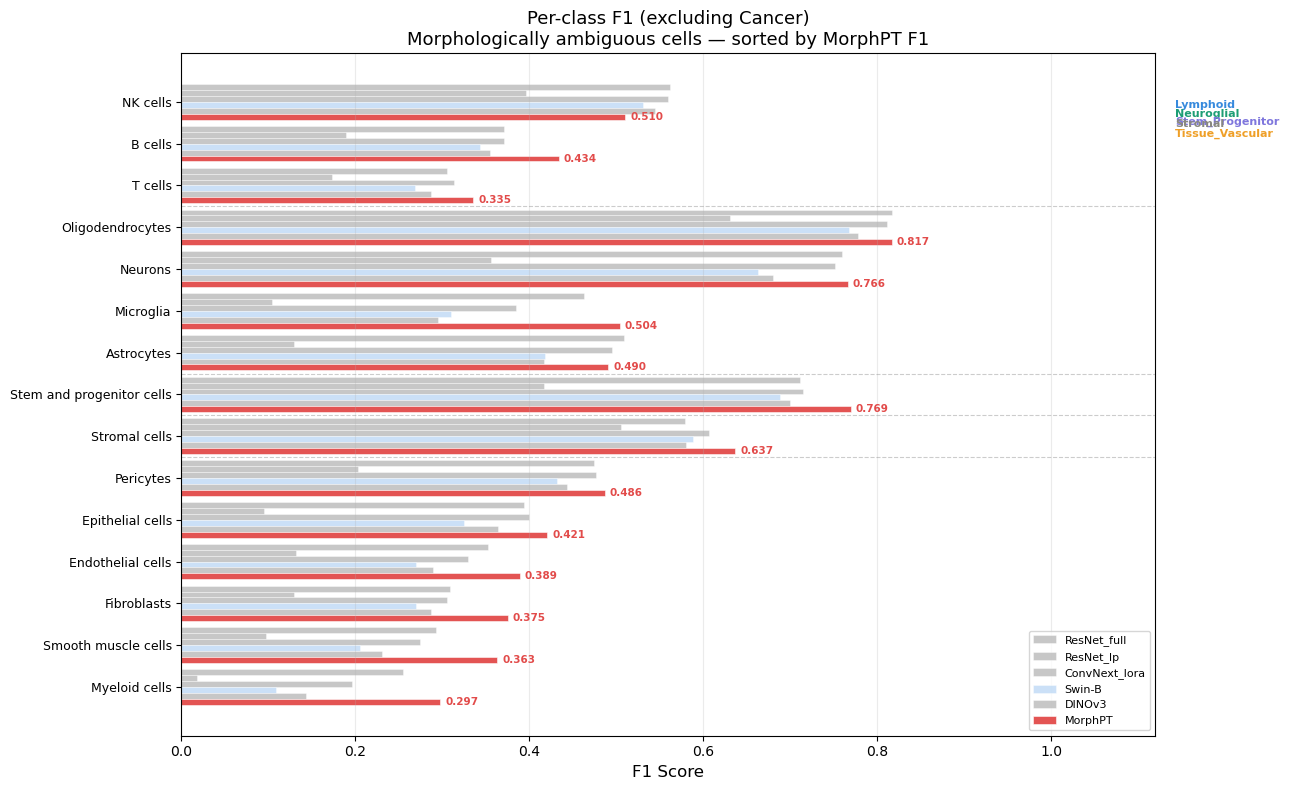

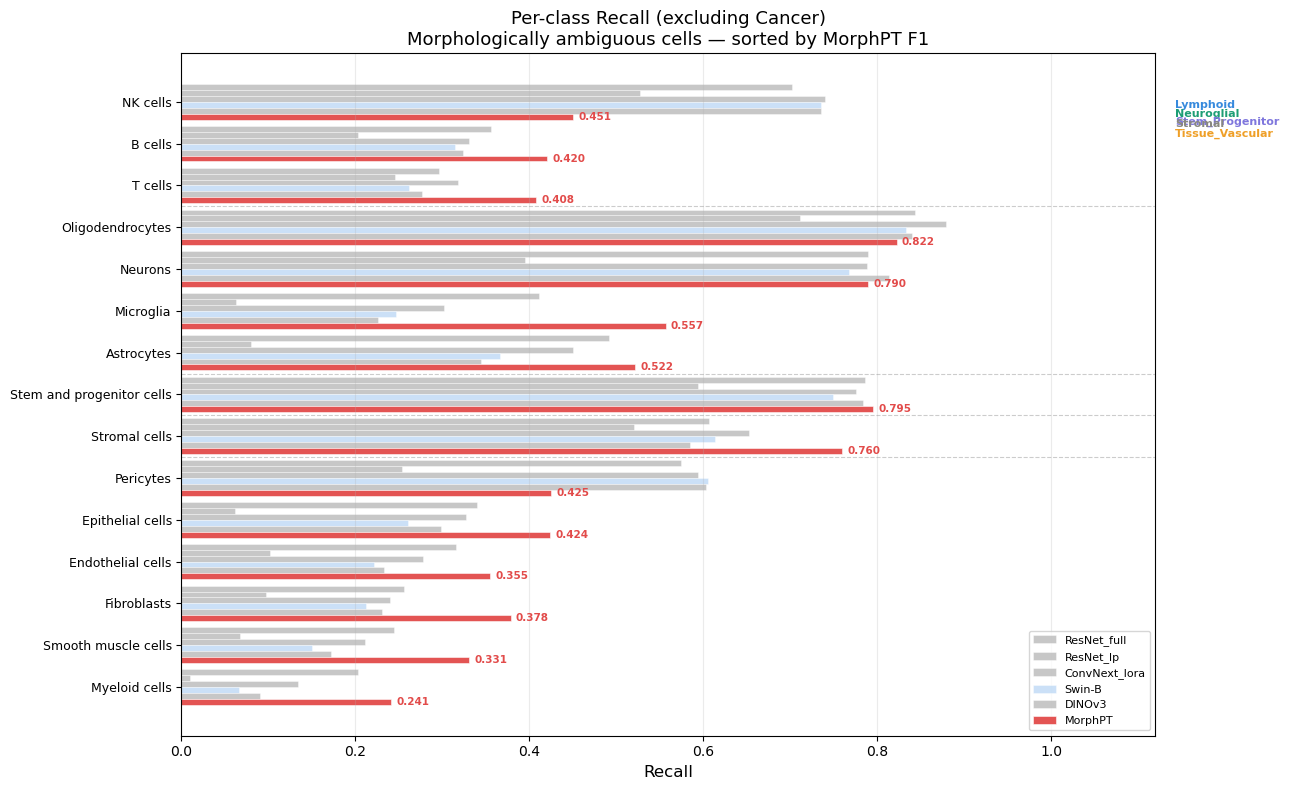


Per-class F1 comparison (excl. Cancer)
  Class                             Coarse              ResNet_fu  ResNet_lp  ConvNext_     Swin-B     DINOv3    MorphPT      ΔF1
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  NK cells                          Lymphoid                0.562      0.396      0.560      0.531      0.544      0.510   -0.051 ↓
  B cells                           Lymphoid                0.371      0.189      0.371      0.344      0.355      0.434   +0.063 ↑
  T cells                           Lymphoid                0.305      0.174      0.313      0.269      0.287      0.335   +0.022 ↑
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Oligodendrocytes                  Neuroglial              0.817      0.631      0.812      0.768      0.778      0.817   -0.001  
  Neurons                           Neur

In [4]:
#!/usr/bin/env python3
"""
Baseline vs MorphPT comparison
==============================
Reads per_class.json from each experiment directory and prints/plots:
  1. Overall score comparison (Macro F1 + Bal Acc + Acc)
  2. Per-coarse-group F1 + Bal Acc grouped bar chart
  3. Per-class F1 (excluding Cancer) grouped bar chart
  4. Per-class Recall (excluding Cancer)
  5. Summary tables

Usage: python scripts/compare_baselines.py
       (set MAIN_ONLY=True for clean main-figure baselines,
        MAIN_ONLY=False to include all supplementary baselines)
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────
MAIN_ONLY = False   # True: core baselines (2.5× single-view + MorphPT)
                   # False: include freeze, 10×, ConvNext variants

# ── Paths ────────────────────────────────────────────────────────────────
BASE         = Path("/hpc/group/jilab/rz179/MorphPT_MOE/experiments")
MORPHPT_RESULT = Path("/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3")

# Main baselines: 2.5× single-view, full finetune (matches paper narrative)
MAIN_PATHS = {
    "ResNet-50\n(2.5×)":      BASE / "baseline_resnet50_freeze_2p5x" / "per_class.json",
    "Swin-B\n(2.5×)":         BASE / "baseline_swin_base_patch4_window7_224_2p5x" / "per_class.json",
    "DINOv3 ViT-B\n(2.5×)":   BASE / "baseline_vit_base_patch16_dinov3.lvd1689m_2p5x" / "per_class.json",
    "MorphPT\n(2.5×+10×)":    MORPHPT_RESULT / "per_class_top1.json",
}

# Supplementary: also include freeze variants, 10× single-view, ConvNext
SUPP_PATHS = {
    "ResNet_full\n(2.5×)":    BASE / "baseline_resnet50_2p5x" / "per_class.json",
    #"ResNet_full\n(10×)":     BASE / "baseline_resnet50_10x" / "per_class.json",
    "ResNet_lp\n(2.5×)":  BASE / "baseline_resnet50_freeze_2p5x" / "per_class.json",
    #"ResNet_lp\n(10×)":   BASE / "baseline_resnet50_freeze_10x" / "per_class.json",
    #"ConvNext\n(2.5×)":          BASE / "baseline_convnextv2_base.fcmae_ft_in22k_in1k_2p5x" / "per_class.json",
    #"ConvNext\n(10×)":           BASE / "baseline_convnextv2_base.fcmae_ft_in22k_in1k_10x" / "per_class.json",
    "ConvNext_lora\n(2.5×)":   "/hpc/group/jilab/tc459/MorphPT/experiments/baseline_convnextv2_base.fcmae_ft_in22k_in1k_lora_2p5x/per_class.json",
    #"ConvNext_lora\n(10×)":   "/hpc/group/jilab/tc459/MorphPT/experiments/baseline_convnextv2_base.fcmae_ft_in22k_in1k_lora_10x/per_class.json",
    "Swin-B\n(2.5×)":            BASE / "baseline_swin_base_patch4_window7_224_2p5x" / "per_class.json",
    #"Swin-B\n(10×)":             BASE / "baseline_swin_base_patch4_window7_224_10x" / "per_class.json",
    "DINOv3\n(2.5×)":      BASE / "baseline_vit_base_patch16_dinov3.lvd1689m_2p5x" / "per_class.json",
    #"DINOv3\n(10×)":       BASE / "baseline_vit_base_patch16_dinov3.lvd1689m_10x" / "per_class.json",
    "MorphPT\n(2.5×+10×)":       MORPHPT_RESULT / "per_class_top1.json",

}

MODEL_PATHS = MAIN_PATHS if MAIN_ONLY else SUPP_PATHS

# Color palette — fallback gray for any unmapped key
DEFAULT_COLOR = "#B0B0B0"
COLOR_PALETTE = {
    # main
    "ResNet-50\n(2.5×)":           "#888780",
    "Swin-B\n(2.5×)":              "#B5D4F4",
    "DINOv3 ViT-B\n(2.5×)":        "#378ADD",
    "MorphPT\n(2.5×+10×)":         "#E24B4A",
    # supplementary variants
    "ResNet-50_full\n(2.5×)":      "#888780",
    "ResNet-50_full\n(10×)":       "#5A5A55",
    "ResNet-50_freeze\n(2.5×)":    "#C7C5BC",
    "ResNet-50_freeze\n(10×)":     "#A09E94",
    "ConvNext\n(2.5×)":            "#9DC9A6",
    "ConvNext\n(10×)":             "#5E8F68",
    "Swin-B\n(10×)":               "#6B9BD0",
    "DINOv3 ViT-B\n(10×)":         "#1E5A9C",
}

def short_name(label):
    """Strip the (view) suffix for compact display."""
    return label.split("\n")[0]

MODEL_COLORS = {m: COLOR_PALETTE.get(m, DEFAULT_COLOR) for m in MODEL_PATHS}
MODEL_SHORT  = {m: short_name(m) for m in MODEL_PATHS}

# ── Class hierarchy ───────────────────────────────────────────────────────
FINE_TO_COARSE = {
    "Colon cancer cells":         "Cancer",
    "Liver cancer cells":         "Cancer",
    "Lung cancer cells":          "Cancer",
    "Ovary cancer cells":         "Cancer",
    "Pancreas cancer cells":      "Cancer",
    "Skin cancer cells":          "Cancer",
    "B cells":                    "Lymphoid",
    "NK cells":                   "Lymphoid",
    "T cells":                    "Lymphoid",
    "Astrocytes":                 "Neuroglial",
    "Microglia":                  "Neuroglial",
    "Neurons":                    "Neuroglial",
    "Oligodendrocytes":           "Neuroglial",
    "Endothelial cells":          "Tissue_Vascular",
    "Epithelial cells":           "Tissue_Vascular",
    "Fibroblasts":                "Tissue_Vascular",
    "Myeloid cells":              "Tissue_Vascular",
    "Pericytes":                  "Tissue_Vascular",
    "Smooth muscle cells":        "Tissue_Vascular",
    "Stem and progenitor cells":  "Stem_Progenitor",
    "Stromal cells":              "Stromal",
}

COARSE_ORDER = ["Cancer", "Lymphoid", "Neuroglial",
                "Stem_Progenitor", "Stromal", "Tissue_Vascular"]

COARSE_ORDER_NO_CANCER = ["Lymphoid", "Neuroglial",
                          "Stem_Progenitor", "Stromal", "Tissue_Vascular"]

COARSE_COLORS = {
    "Cancer":          "#E24B4A",
    "Lymphoid":        "#378ADD",
    "Neuroglial":      "#1D9E75",
    "Tissue_Vascular": "#EF9F27",
    "Stem_Progenitor": "#7F77DD",
    "Stromal":         "#888780",
}


# ── Load data ─────────────────────────────────────────────────────────────

def load_per_class(path):
    rows = json.loads(Path(path).read_text())
    return {r["class"]: r for r in rows}

print(f"Mode: {'MAIN_ONLY' if MAIN_ONLY else 'FULL (with supplementary)'}")
print("Loading results...")
RESULTS_RAW = {}
for model, path in MODEL_PATHS.items():
    p = Path(path)
    if not p.exists():
        print(f"  WARNING: {p} not found — skipping {MODEL_SHORT[model]}")
        continue
    RESULTS_RAW[model] = load_per_class(p)
    print(f"  Loaded {MODEL_SHORT[model]}: {len(RESULTS_RAW[model])} classes")

models       = list(RESULTS_RAW.keys())
morphpt_key  = next((m for m in models if "MorphPT" in m), None)
bl_models    = [m for m in models if m != morphpt_key]
all_classes  = sorted(RESULTS_RAW[models[0]].keys())


def get_metric(model, cls, metric):
    return RESULTS_RAW.get(model, {}).get(cls, {}).get(metric, 0.0)


# ── Sorted fine classes (all + non-cancer) ────────────────────────────────

def make_sorted_classes(coarse_list):
    out = []
    for coarse in coarse_list:
        fines = [c for c in all_classes if FINE_TO_COARSE.get(c) == coarse]
        # Sort within each coarse group by MorphPT F1 (fallback: first model)
        sort_key_model = morphpt_key if morphpt_key else models[0]
        fines_sorted = sorted(
            fines,
            key=lambda c: get_metric(sort_key_model, c, "f1"),
            reverse=True
        )
        out += fines_sorted
    return out

sorted_all       = make_sorted_classes(COARSE_ORDER)
sorted_no_cancer = make_sorted_classes(COARSE_ORDER_NO_CANCER)


# ── Overall scores ─────────────────────────────────────────────────────────

def compute_overall(class_list):
    result = {}
    for model, class_data in RESULTS_RAW.items():
        subset = [class_data[c] for c in class_list
                  if c in class_data and class_data[c].get("n", 0) > 0]
        total_n  = sum(r["n"] for r in subset)
        total_tp = sum(round(r["rec"] * r["n"]) for r in subset)
        result[model] = {
            "macro_f1": round(float(np.mean([r["f1"]  for r in subset])), 4),
            "bal_acc":  round(float(np.mean([r["rec"] for r in subset])), 4),
            "acc":      round(total_tp / total_n, 4) if total_n > 0 else 0.0,
        }
    return result

OVERALL_ALL       = compute_overall(all_classes)
OVERALL_NO_CANCER = compute_overall(sorted_no_cancer)

print("\nOverall (all 21 classes):")
print(f"  {'Model':<25} {'Macro F1':>10} {'Bal Acc':>10} {'Acc':>10}")
print("  " + "─"*57)
for m in models:
    s = OVERALL_ALL[m]
    print(f"  {MODEL_SHORT[m]:<25} {s['macro_f1']:>10.4f} {s['bal_acc']:>10.4f} {s['acc']:>10.4f}")

print("\nOverall (15 classes, excl. Cancer):")
print(f"  {'Model':<25} {'Macro F1':>10} {'Bal Acc':>10} {'Acc':>10}")
print("  " + "─"*57)
for m in models:
    s = OVERALL_NO_CANCER[m]
    print(f"  {MODEL_SHORT[m]:<25} {s['macro_f1']:>10.4f} {s['bal_acc']:>10.4f} {s['acc']:>10.4f}")


# ── Per-coarse scores ──────────────────────────────────────────────────────

def coarse_scores(model, coarse, metric):
    fines = [c for c in all_classes
             if FINE_TO_COARSE.get(c) == coarse
             and get_metric(model, c, "n") > 0]
    vals = [get_metric(model, c, metric) for c in fines]
    return float(np.mean(vals)) if vals else 0.0

COARSE_F1  = {m: {c: round(coarse_scores(m, c, "f1"),  4) for c in COARSE_ORDER} for m in models}
COARSE_BAL = {m: {c: round(coarse_scores(m, c, "rec"), 4) for c in COARSE_ORDER} for m in models}


# ── Helper: separator lines ────────────────────────────────────────────────

def add_separators(ax, cls_list, coarse_list):
    pos = 0
    n   = len(cls_list)
    for coarse in coarse_list:
        count = sum(1 for c in cls_list if FINE_TO_COARSE.get(c) == coarse)
        if count == 0:
            continue
        mid = pos + count / 2 - 0.5
        if pos > 0:
            ax.axhline(pos - 0.5, color="gray", linewidth=0.8,
                       linestyle="--", alpha=0.4)
        ax.text(1.02, mid / n, coarse,
                transform=ax.get_yaxis_transform(),
                fontsize=8, va="center",
                color=COARSE_COLORS.get(coarse, "gray"),
                fontweight="bold")
        pos += count


# ═══════════════════════════════════════════════════════════════
# Fig 1. Overall score comparison (all 21 classes)
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(max(11, 1.2 * len(models)), 5))
x     = np.arange(len(models))
width = 0.25
y_min = 0.30

f1_vals  = [OVERALL_ALL[m]["macro_f1"] for m in models]
bal_vals = [OVERALL_ALL[m]["bal_acc"]  for m in models]
acc_vals = [OVERALL_ALL[m]["acc"]      for m in models]
colors   = [MODEL_COLORS[m] for m in models]

bars1 = ax.bar(x - width, f1_vals,  width, color=colors, alpha=0.92,
               label="Macro F1", edgecolor="white", linewidth=0.5)
bars2 = ax.bar(x,         bal_vals, width, color=colors, alpha=0.60, label="Balanced Acc", edgecolor="white", linewidth=0.5, hatch="//")
bars3 = ax.bar(x + width, acc_vals, width, color=colors, alpha=0.35,
               label="Accuracy", edgecolor="white", linewidth=0.5, hatch="xx")

for bar, val in zip(list(bars1) + list(bars3), f1_vals + acc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f"{val:.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([MODEL_SHORT[m] for m in models], fontsize=10)
ax.set_ylim(y_min, 0.80)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Overall Performance — All 21 Classes\nSingle-view baselines vs MorphPT",
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
if morphpt_key in models:
    ax.get_xticklabels()[models.index(morphpt_key)].set_fontweight("bold")
    ax.get_xticklabels()[models.index(morphpt_key)].set_color("#E24B4A")

plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════
# Fig 2. Per-coarse-group F1 and Bal Acc
# ═══════════════════════════════════════════════════════════════

fig, (ax_f1, ax_bal) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

n_coarse      = len(COARSE_ORDER)
xc            = np.arange(n_coarse)
cw            = 0.85 / max(len(models), 1)
coarse_labels = [c.replace("_", "\n") for c in COARSE_ORDER]

for ax, score_dict, title, metric_label in [
    (ax_f1,  COARSE_F1,  "Macro F1 by Coarse Group",     "Macro F1"),
    (ax_bal, COARSE_BAL, "Balanced Acc by Coarse Group", "Balanced Acc"),
]:
    for mi, model in enumerate(models):
        offset = (mi - len(models)/2 + 0.5) * cw
        vals   = [score_dict[model][c] for c in COARSE_ORDER]
        lw     = 1.2 if model == morphpt_key else 0.3
        alpha  = 0.95 if model == morphpt_key else 0.70
        bars   = ax.bar(xc + offset, vals, cw,
                        color=MODEL_COLORS[model], alpha=alpha,
                        label=MODEL_SHORT[model],
                        edgecolor="white", linewidth=lw)
        if model == morphpt_key:
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.007,
                        f"{val:.3f}", ha="center", va="bottom",
                        fontsize=7.5, color="#E24B4A", fontweight="bold")

    ax.set_xticks(xc)
    ax.set_xticklabels(coarse_labels, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")

    for tick, coarse in zip(ax.get_xticklabels(), COARSE_ORDER):
        tick.set_color(COARSE_COLORS.get(coarse, "black"))
        tick.set_fontweight("bold")

fig.suptitle("Performance by Coarse Group — MorphPT vs Single-view Baselines",
             fontsize=13)
plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════
# Fig 3. Per-class F1 (excluding Cancer)
# ═══════════════════════════════════════════════════════════════
nc = len(sorted_no_cancer)
nm = len(models)
h  = 0.85 / max(nm, 1)
y  = np.arange(nc)

fig, ax = plt.subplots(figsize=(13, max(8, 0.5 * nc)))

for mi, model in enumerate(models):
    offset = (mi - nm/2 + 0.5) * h
    vals   = [get_metric(model, c, "f1") for c in sorted_no_cancer]
    alpha  = 0.95 if model == morphpt_key else 0.70
    ax.barh(y + offset, vals, height=h,
            color=MODEL_COLORS[model], alpha=alpha,
            label=MODEL_SHORT[model],
            edgecolor="white", linewidth=0.4)

if morphpt_key in RESULTS_RAW:
    for i, cls in enumerate(sorted_no_cancer):
        val = get_metric(morphpt_key, cls, "f1")
        ax.text(val + 0.006, i + (nm/2 - 0.5) * h,
                f"{val:.3f}", va="center", fontsize=7.5,
                color="#E24B4A", fontweight="bold")

add_separators(ax, sorted_no_cancer, COARSE_ORDER_NO_CANCER)

ax.set_yticks(y)
ax.set_yticklabels(sorted_no_cancer, fontsize=9)
ax.set_xlabel("F1 Score", fontsize=12)
ax.set_xlim(0, 1.12)
ax.set_title("Per-class F1 (excluding Cancer)\n"
             "Morphologically ambiguous cells — sorted by MorphPT F1",
             fontsize=13)
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()

plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════
# Fig 4. Per-class Recall (excluding Cancer)
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, max(8, 0.5 * nc)))

for mi, model in enumerate(models):
    offset = (mi - nm/2 + 0.5) * h
    vals   = [get_metric(model, c, "rec") for c in sorted_no_cancer]
    alpha  = 0.95 if model == morphpt_key else 0.70
    ax.barh(y + offset, vals, height=h,
            color=MODEL_COLORS[model], alpha=alpha,
            label=MODEL_SHORT[model],
            edgecolor="white", linewidth=0.4)

if morphpt_key in RESULTS_RAW:
    for i, cls in enumerate(sorted_no_cancer):
        val = get_metric(morphpt_key, cls, "rec")
        ax.text(val + 0.006, i + (nm/2 - 0.5) * h,
                f"{val:.3f}", va="center", fontsize=7.5,
                color="#E24B4A", fontweight="bold")

add_separators(ax, sorted_no_cancer, COARSE_ORDER_NO_CANCER)

ax.set_yticks(y)
ax.set_yticklabels(sorted_no_cancer, fontsize=9)
ax.set_xlabel("Recall", fontsize=12)
ax.set_xlim(0, 1.12)
ax.set_title("Per-class Recall (excluding Cancer)\n"
             "Morphologically ambiguous cells — sorted by MorphPT F1",
             fontsize=13)
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", alpha=0.25)
ax.invert_yaxis()

plt.tight_layout()
plt.show()


# ── Summary table ─────────────────────────────────────────────────────────

print("\n" + "="*100)
print("Per-class F1 comparison (excl. Cancer)")
print("="*100)

# Build header dynamically based on number of models
header_models = " ".join(f"{MODEL_SHORT[m][:9]:>10}" for m in models)
print(f"  {'Class':<33} {'Coarse':<18} {header_models} {'ΔF1':>8}")
print("  " + "─"*(53 + 11*len(models) + 9))

prev_coarse = None
for cls in sorted_no_cancer:
    coarse = FINE_TO_COARSE.get(cls, "?")
    if coarse != prev_coarse:
        if prev_coarse is not None:
            print(f"  {'─'*(53 + 11*len(models) + 9)}")
        prev_coarse = coarse
    vals     = [get_metric(m, cls, "f1") for m in models]
    bl_vals  = [get_metric(m, cls, "f1") for m in bl_models]
    morphpt_val = get_metric(morphpt_key, cls, "f1") if morphpt_key else 0.0
    best_bl  = max(bl_vals) if bl_vals else 0.0
    delta    = morphpt_val - best_bl
    flag     = " ↑" if delta > 0.01 else (" ↓" if delta < -0.01 else "  ")
    val_str  = " ".join(f"{v:>10.3f}" for v in vals)
    print(f"  {cls:<33} {coarse:<18} {val_str} {delta:>+8.3f}{flag}")

print("\n" + "="*100)
print("Overall scores")
print("="*100)
print(f"  {'Model':<25} {'All 21 — F1':>12} {'All 21 — Bal':>13}"
      f" {'No Cancer — F1':>15} {'No Cancer — Bal':>16}")
print("  " + "─"*83)
for m in models:
    a = OVERALL_ALL[m]
    b = OVERALL_NO_CANCER[m]
    print(f"  {MODEL_SHORT[m]:<25} {a['macro_f1']:>12.4f} {a['bal_acc']:>13.4f}"
          f" {b['macro_f1']:>15.4f} {b['bal_acc']:>16.4f}")

print("\nDone.")

## SHOWCASE TEST PATCHES 可视化

In [6]:
import pandas as pd
import numpy as np

# 1. 加载你的最终预测结果
df = pd.read_parquet("/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3/predictions.parquet")
all_fine_classes = sorted(df["label"].unique())

def compute_slide_metrics(group):
    """计算单个 Slide 的指标"""
    y_true = group["label"].values
    y_pred = group["pred_top1"].values
    
    # 使用你之前的逻辑计算 BACC
    # 注意：如果某个 Slide 缺失某些类，BACC 只计算存在的类
    name_to_idx = {n: i for i, n in enumerate(all_fine_classes)}
    true_idx = np.array([name_to_idx.get(y, -1) for y in y_true])
    pred_idx = np.array([name_to_idx.get(y, -1) for y in y_pred])
    
    recalls = []
    present_classes = np.unique(true_idx)
    for i in present_classes:
        tp = ((true_idx == i) & (pred_idx == i)).sum()
        fn = ((true_idx == i) & (pred_idx != i)).sum()
        recalls.append(tp / max(tp + fn, 1))
    
    bal_acc = np.mean(recalls) if recalls else 0
    acc = (true_idx == pred_idx).sum() / len(true_idx)
    avg_margin = group["router_margin"].mean()
    
    return pd.Series({
        "n_cells": len(group),
        "bacc": round(bal_acc, 4),
        "acc": round(acc, 4),
        "avg_margin": round(avg_margin, 4),
        "n_classes": len(present_classes)
    })

# 2. 按 Slide 分组并计算
slide_stats = df.groupby("tissue").apply(compute_slide_metrics).sort_values("bacc", ascending=False)

# 3. 输出 Top 5 (好的) 和 Bottom 5 (差的)
print(f"\n{'═'*80}")
print(f"  TOP PERFORMING SLIDES (Potentially good for Showcase)")
print(f"{'═'*80}")
print(slide_stats.head(15).to_string())

print(f"\n{'═'*80}")
print(f"  BOTTOM 5 PERFORMING SLIDES (Challenge areas)")
print(f"{'═'*80}")
print(slide_stats.tail(5).to_string())


════════════════════════════════════════════════════════════════════════════════
  TOP PERFORMING SLIDES (Potentially good for Showcase)
════════════════════════════════════════════════════════════════════════════════
                                         n_cells    bacc     acc  avg_margin  n_classes
tissue                                                                                 
Xenium_V1_hColon_Non_diseased_Add_on      3302.0  0.6852  0.7544      0.7439        5.0
Xenium_V1_hColon_Non_diseased_Base        4299.0  0.6182  0.7441      0.7532        5.0
Xenium_V1_hColon_Cancer_Add_on            8809.0  0.5356  0.7689      0.6470        5.0
Xenium_V1_hLiver_nondiseased              3261.0  0.5040  0.5090      0.5745        7.0
Xenium_V1_hSkin_nondiseased_section_1     2454.0  0.4980  0.5424      0.8001        6.0
Xenium_V1_FFPE_Human_Brain_Healthy        5652.0  0.4897  0.6384      0.8638        6.0
Xenium_V1_hSkin_Melanoma_Base             7456.0  0.4888  0.7839      0.7053 

/tmp/ipykernel_1005377/3478703964.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  slide_stats = df.groupby("tissue").apply(compute_slide_metrics).sort_values("bacc", ascending=False)


In [2]:
import pandas as pd
from pathlib import Path

root_path = "/hpc/group/jilab/rz179/MorphPT_MOE/"

RESULTS = {
    "Colon_Add_on": root_path + "results/showcase/Xenium_V1_hColon_Non_diseased_Add_on/predictions.parquet",
    "Colon_Base":  root_path + "results/showcase/Xenium_V1_hColon_Non_diseased_Base/predictions.parquet",
    "Brain_Healthy":root_path +"results/showcase/Xenium_V1_FFPE_Human_Brain_Healthy/predictions.parquet",
}

for name, path in RESULTS.items():
    df = pd.read_parquet(path)
    print(f"\n{'='*60}")
    print(f"{name}  ({len(df):,} cells)")
    print(f"{'='*60}")

    patch_stats = df.groupby("patch_id").agg(
        n_cells      = ("label", "count"),
        n_classes    = ("label", "nunique"),
        acc          = ("label", lambda x: (x == df.loc[x.index, "pred_top1"]).mean()),
        avg_margin   = ("router_margin", "mean"),
        x_min        = ("x_centroid", "min"),
        x_max        = ("x_centroid", "max"),
        y_min        = ("y_centroid", "min"),
        y_max        = ("y_centroid", "max"),
    ).round(3)

    # Balanced acc per patch
    bal_accs = []
    for pid, grp in df.groupby("patch_id"):
        recs = grp.groupby("label").apply(
            lambda g: (g["label"] == g["pred_top1"]).mean()
        )
        bal_accs.append(recs.mean())
    patch_stats["bal_acc"] = [round(b, 3) for b in bal_accs]

    print(patch_stats[["n_cells","n_classes","bal_acc","acc",
                        "avg_margin"]].to_string())


Colon_Add_on  (33,185 cells)


/tmp/ipykernel_1005377/3975617255.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recs = grp.groupby("label").apply(
/tmp/ipykernel_1005377/3975617255.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recs = grp.groupby("label").apply(
/tmp/ipykernel_1005377/3975617255.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas 

          n_cells  n_classes  bal_acc    acc  avg_margin
patch_id                                                
3            4237          5    0.500  0.478       0.630
5            3130          4    0.403  0.882       0.687
14           8651          5    0.574  0.535       0.695
20           4122          4    0.295  0.884       0.652
23          13045          5    0.634  0.586       0.724

Colon_Base  (45,895 cells)
          n_cells  n_classes  bal_acc    acc  avg_margin
patch_id                                                
3            6608          5    0.583  0.553       0.692
5            3359          5    0.413  0.833       0.636
12          23277          5    0.609  0.558       0.670
19           9823          5    0.568  0.556       0.767
20           2828          4    0.462  0.817       0.629

Brain_Healthy  (6,209 cells)
          n_cells  n_classes  bal_acc    acc  avg_margin
patch_id                                                
11           1043          6  

/tmp/ipykernel_1005377/3975617255.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recs = grp.groupby("label").apply(
/tmp/ipykernel_1005377/3975617255.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recs = grp.groupby("label").apply(
/tmp/ipykernel_1005377/3975617255.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas 


Colon Non-diseased (Patch 23)
  cells=3,130  classes=4  acc=0.882  margin=0.687
  Class distribution:
    Myeloid cells                        3,061 (97.8%)
    T cells                                 54 (1.7%)
    B cells                                 13 (0.4%)
    Epithelial cells                         2 (0.1%)


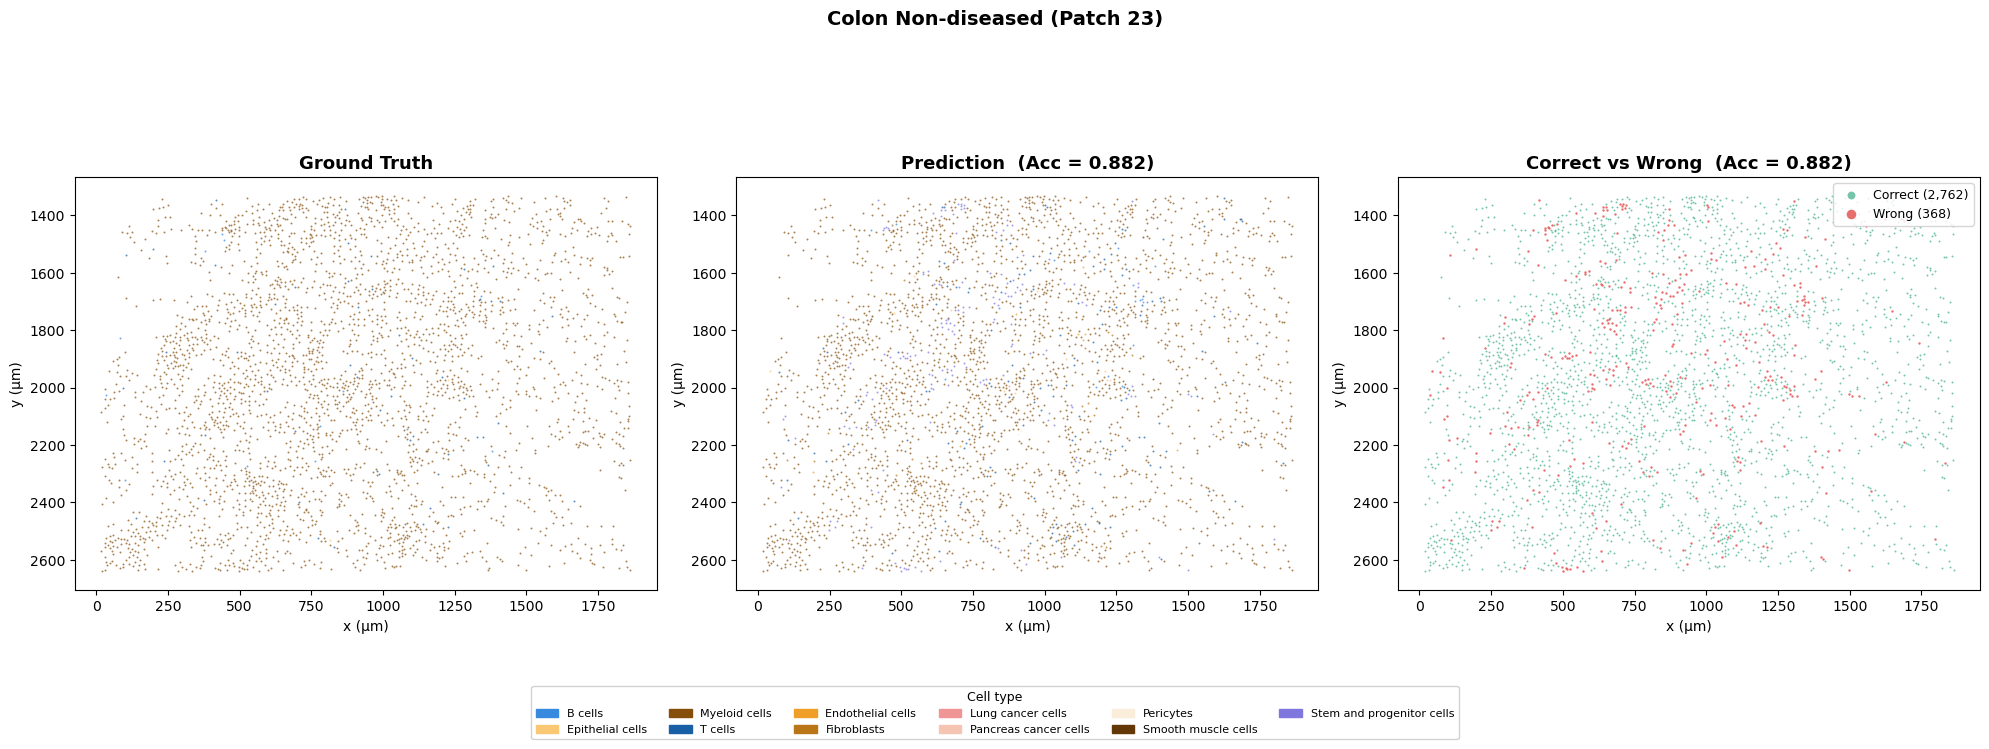

Saved: results/showcase/figures/Colon_Non-diseased_Patch_23_comparison.png


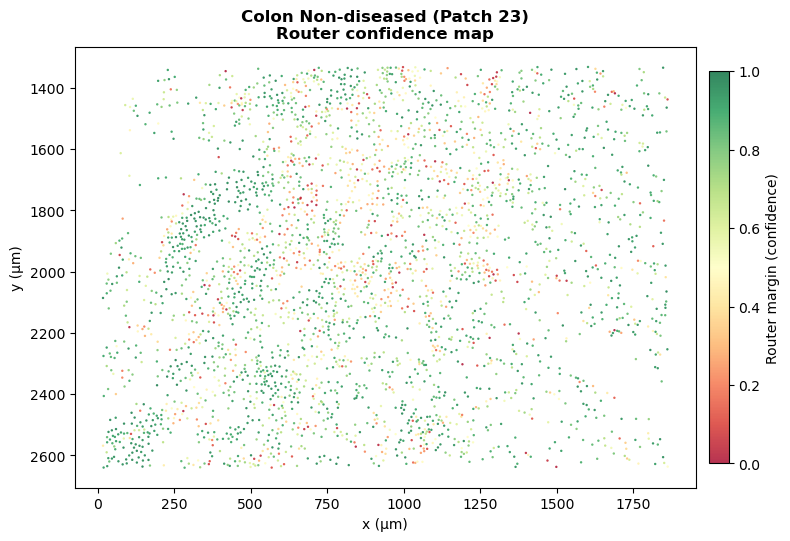

Saved: results/showcase/figures/Colon_Non-diseased_Patch_23_confidence.png

Brain Healthy (Patch 21)
  cells=1,471  classes=6  acc=0.695  margin=0.879
  Class distribution:
    Neurons                                573 (39.0%)
    Oligodendrocytes                       500 (34.0%)
    Astrocytes                             161 (10.9%)
    Endothelial cells                      112 (7.6%)
    Microglia                               82 (5.6%)
    Stromal cells                           43 (2.9%)


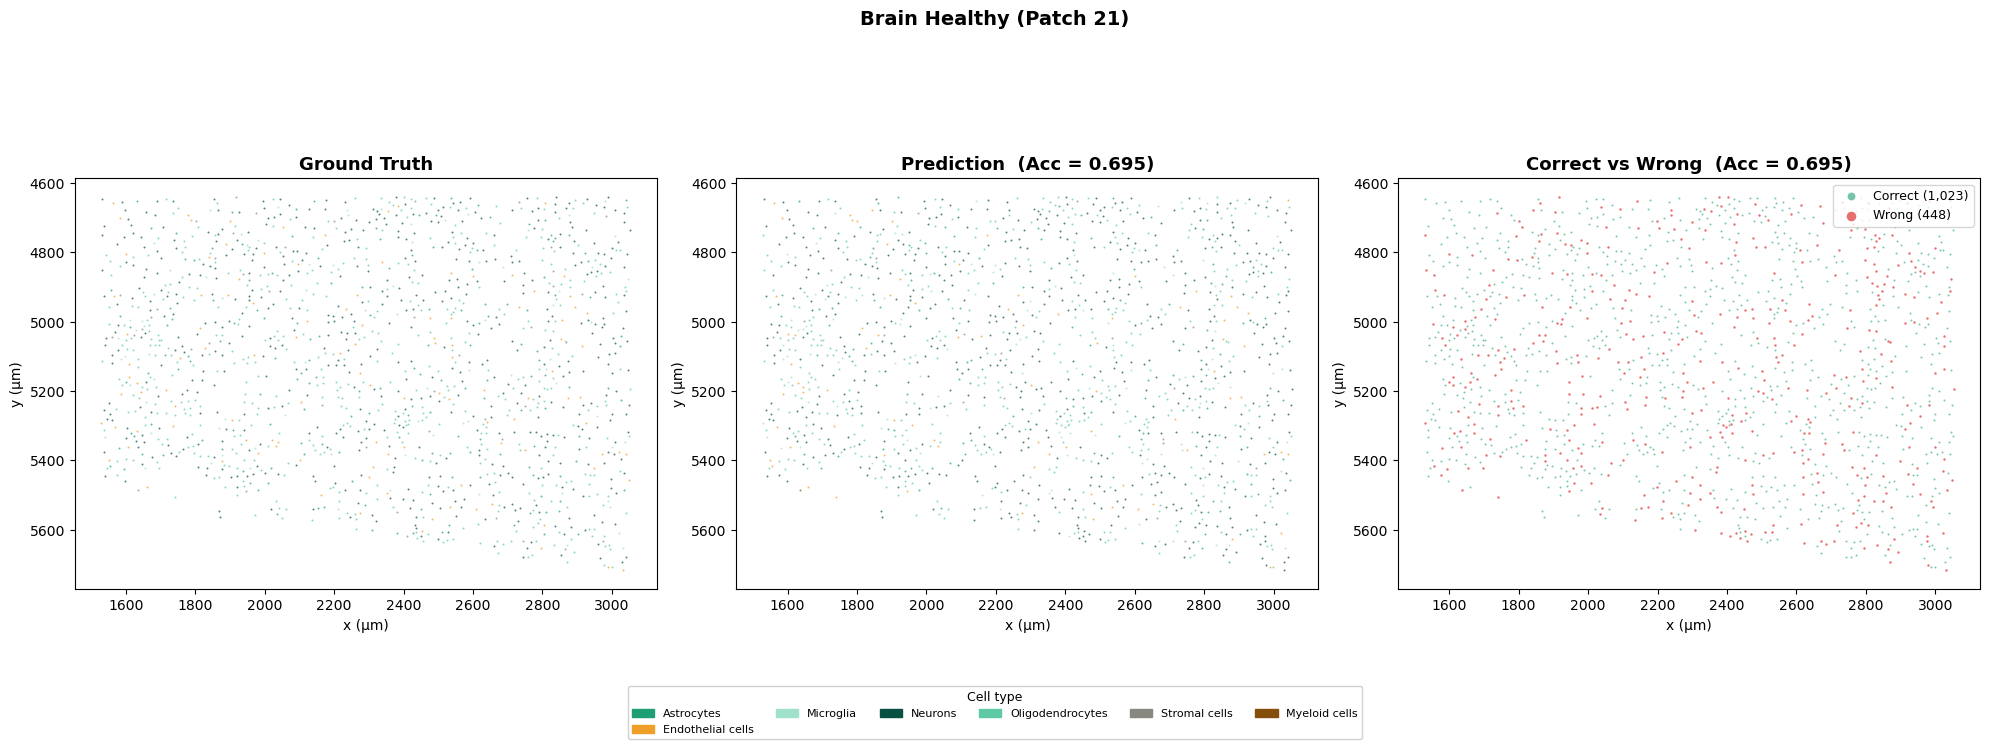

Saved: results/showcase/figures/Brain_Healthy_Patch_21_comparison.png


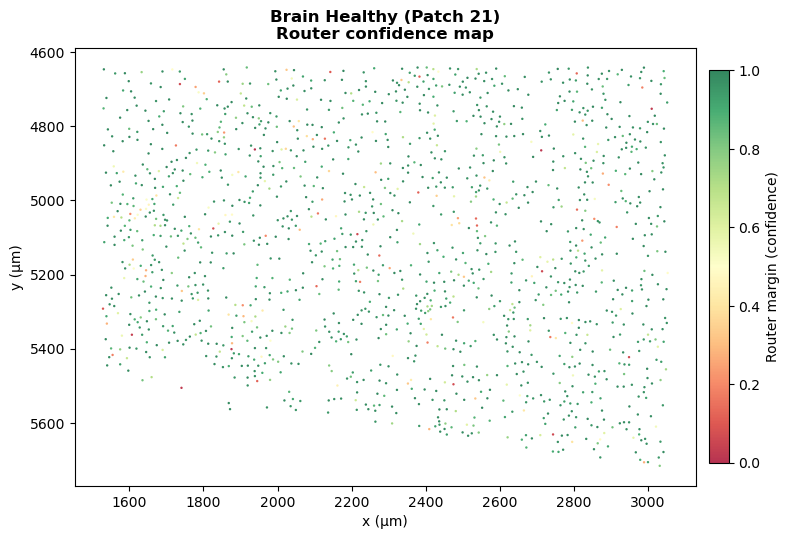

Saved: results/showcase/figures/Brain_Healthy_Patch_21_confidence.png


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

root_path = "/hpc/group/jilab/rz179/MorphPT_MOE/"

# ── Config ────────────────────────────────────────────────────
SELECTED = {
    "Colon Non-diseased\n(Patch 23)": (
        root_path + "results/showcase/Xenium_V1_hColon_Non_diseased_Add_on/predictions.parquet", 5),
    "Brain Healthy\n(Patch 21)": (
        root_path + "results/showcase/Xenium_V1_FFPE_Human_Brain_Healthy/predictions.parquet", 21),
}

# Color palette for fine classes
FINE_COLORS = {
    # Cancer
    "Colon cancer cells":         "#E24B4A",
    "Liver cancer cells":         "#A32D2D",
    "Lung cancer cells":          "#F09595",
    "Ovary cancer cells":         "#D85A30",
    "Pancreas cancer cells":      "#F5C4B3",
    "Skin cancer cells":          "#993C1D",
    # Lymphoid
    "B cells":                    "#378ADD",
    "NK cells":                   "#85B7EB",
    "T cells":                    "#185FA5",
    # Neuroglial
    "Astrocytes":                 "#1D9E75",
    "Microglia":                  "#9FE1CB",
    "Neurons":                    "#085041",
    "Oligodendrocytes":           "#5DCAA5",
    # Tissue_Vascular
    "Endothelial cells":          "#EF9F27",
    "Epithelial cells":           "#FAC775",
    "Fibroblasts":                "#BA7517",
    "Myeloid cells":              "#854F0B",
    "Pericytes":                  "#FAEEDA",
    "Smooth muscle cells":        "#633806",
    # Singletons
    "Stem and progenitor cells":  "#7F77DD",
    "Stromal cells":              "#888780",
}

DOT_SIZE  = 2     # point size, adjust based on cell density
DPI       = 150


def plot_spatial_comparison(df, title, out_path):
    """
    Two-panel plot: Ground Truth (left) vs Prediction (right).
    Third panel: correct/wrong highlight.
    """
    classes    = sorted(df["label"].unique())
    pred_only  = sorted(set(df["pred_top1"].unique()) - set(classes))
    all_shown  = classes + pred_only

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    # ── Panel 1: Ground Truth ──
    ax = axes[0]
    for cls in classes:
        sub = df[df["label"] == cls]
        ax.scatter(sub["x_centroid"], sub["y_centroid"],
                   c=FINE_COLORS.get(cls, "#cccccc"),
                   s=DOT_SIZE, alpha=0.7, linewidths=0, label=cls)
    ax.set_title("Ground Truth", fontsize=13, fontweight="bold")
    ax.set_xlabel("x (µm)", fontsize=10)
    ax.set_ylabel("y (µm)", fontsize=10)
    ax.set_aspect("equal")
    ax.invert_yaxis()

    # ── Panel 2: Prediction ──
    ax = axes[1]
    for cls in all_shown:
        sub = df[df["pred_top1"] == cls]
        if len(sub) == 0:
            continue
        ax.scatter(sub["x_centroid"], sub["y_centroid"],
                   c=FINE_COLORS.get(cls, "#cccccc"),
                   s=DOT_SIZE, alpha=0.7, linewidths=0, label=cls)
    acc = (df["label"] == df["pred_top1"]).mean()
    ax.set_title(f"Prediction  (Acc = {acc:.3f})", fontsize=13, fontweight="bold")
    ax.set_xlabel("x (µm)", fontsize=10)
    ax.set_ylabel("y (µm)", fontsize=10)
    ax.set_aspect("equal")
    ax.invert_yaxis()

    # ── Panel 3: Correct / Wrong ──
    ax = axes[2]
    correct = df[df["label"] == df["pred_top1"]]
    wrong   = df[df["label"] != df["pred_top1"]]

    ax.scatter(correct["x_centroid"], correct["y_centroid"],
               c="#1D9E75", s=DOT_SIZE, alpha=0.6, linewidths=0,
               label=f"Correct ({len(correct):,})")
    ax.scatter(wrong["x_centroid"], wrong["y_centroid"],
               c="#E24B4A", s=DOT_SIZE + 1, alpha=0.8, linewidths=0,
               label=f"Wrong ({len(wrong):,})")

    ax.set_title(f"Correct vs Wrong  (Acc = {acc:.3f})", fontsize=13, fontweight="bold")
    ax.set_xlabel("x (µm)", fontsize=10)
    ax.set_ylabel("y (µm)", fontsize=10)
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.legend(fontsize=9, markerscale=4, loc="upper right")

    # ── Shared legend for panels 1 & 2 ──
    handles = [mpatches.Patch(color=FINE_COLORS.get(c, "#cccccc"), label=c)
               for c in all_shown if c in FINE_COLORS]
    fig.legend(handles=handles, fontsize=8,
               loc="lower center", ncol=min(len(handles), 6),
               bbox_to_anchor=(0.5, -0.04), framealpha=0.9,
               title="Cell type", title_fontsize=9)

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(out_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


def plot_confidence_map(df, title, out_path):
    """
    Spatial map colored by router margin (confidence).
    """
    fig, ax = plt.subplots(figsize=(8, 7))

    sc = ax.scatter(df["x_centroid"], df["y_centroid"],
                    c=df["router_margin"],
                    cmap="RdYlGn", vmin=0, vmax=1,
                    s=DOT_SIZE + 1, alpha=0.8, linewidths=0)

    plt.colorbar(sc, ax=ax, label="Router margin (confidence)",
                 fraction=0.03, pad=0.02)
    ax.set_title(f"{title}\nRouter confidence map", fontsize=12, fontweight="bold")
    ax.set_xlabel("x (µm)", fontsize=10)
    ax.set_ylabel("y (µm)", fontsize=10)
    ax.set_aspect("equal")
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig(out_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


# ── Run ───────────────────────────────────────────────────────

OUT = Path("results/showcase/figures")
OUT.mkdir(parents=True, exist_ok=True)

for name, (path, patch_id) in SELECTED.items():
    df = pd.read_parquet(path)
    df = df[df["patch_id"] == patch_id].reset_index(drop=True)

    n      = len(df)
    n_cls  = df["label"].nunique()
    acc    = (df["label"] == df["pred_top1"]).mean()
    margin = df["router_margin"].mean()

    print(f"\n{'='*55}")
    print(f"{name.replace(chr(10), ' ')}")
    print(f"  cells={n:,}  classes={n_cls}  acc={acc:.3f}  margin={margin:.3f}")
    print(f"  Class distribution:")
    for cls, cnt in df["label"].value_counts().items():
        print(f"    {cls:<35} {cnt:>6,} ({100*cnt/n:.1f}%)")

    safe_name = name.replace("\n", "_").replace(" ", "_").replace("(", "").replace(")", "")

    # Main comparison plot
    plot_spatial_comparison(
        df, title=name.replace("\n", " "),
        out_path=OUT / f"{safe_name}_comparison.png"
    )

    # Confidence map
    plot_confidence_map(
        df, title=name.replace("\n", " "),
        out_path=OUT / f"{safe_name}_confidence.png"
    )

## TODO
1. Gate weight 可视化
每个 expert 学到的 2.5x/10x 权重分布，现在只有均值，可以画成每个细类的分布图——看不同细类是否有系统性的尺度偏好。predictions.parquet 里有 gate_2_5x 和 gate_10x 列。
2. Normal vs Cancer tissue 分层表现
之前分析过这个，可以做成图：同一细类在 normal 和 cancer tissue 里的 F1 对比，直观展示 tissue context 污染的影响。
3. Spatial visualization
用 showcase slide（Lung Cancer）的坐标数据，画一张空间散点图，颜色代表预测是否正确，直观展示误分类的空间分布模式。

Loaded 167,401 cells
Gate columns: gate_2_5x mean=0.235, gate_10x mean=0.765


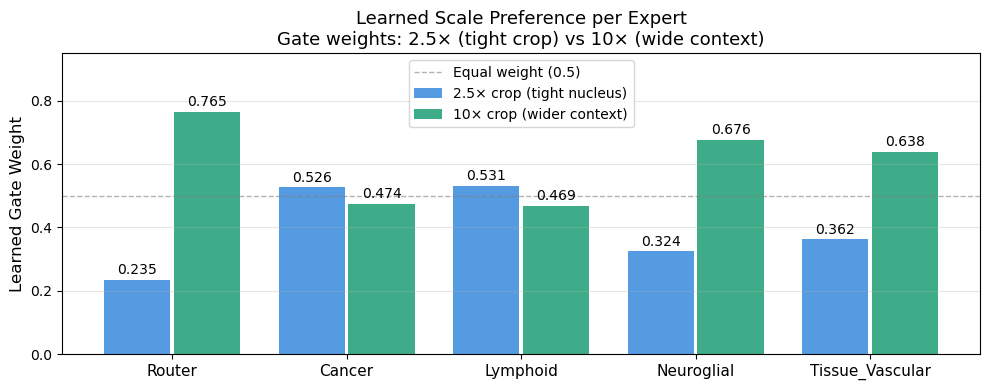

Saved: gate_expert_summary.png


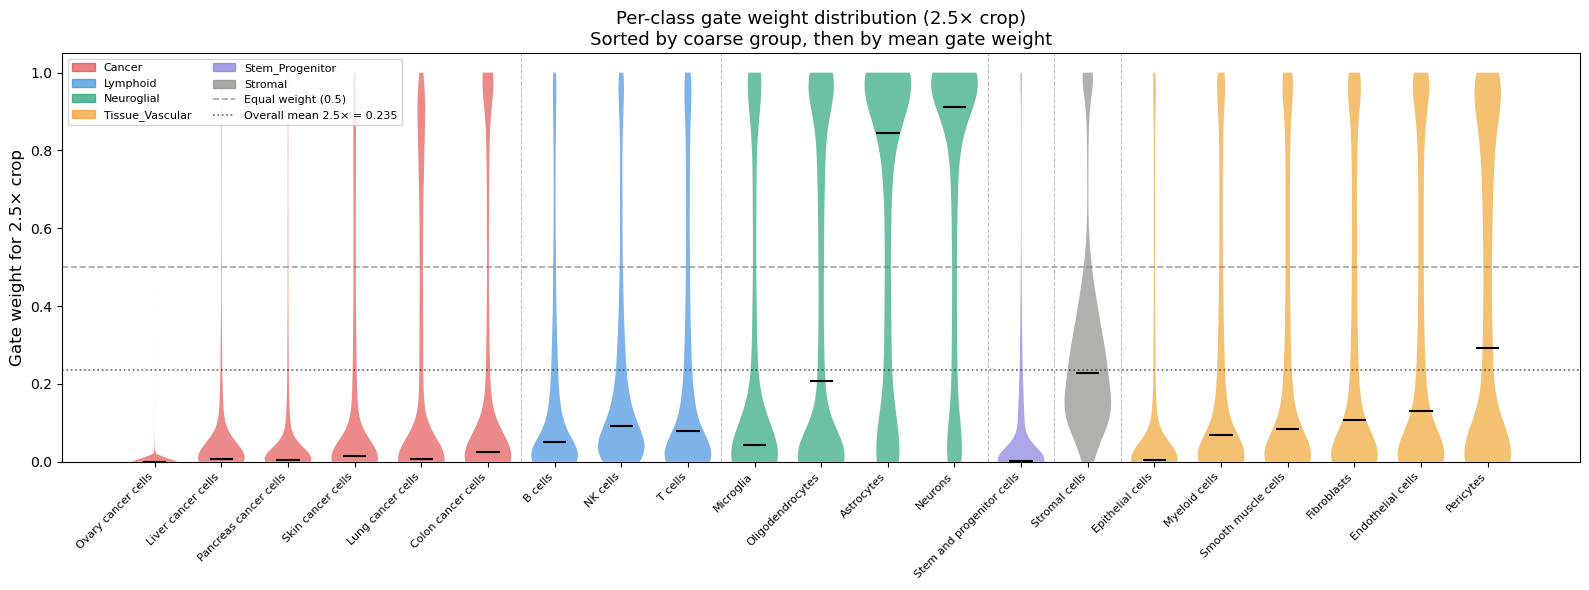

Saved: gate_per_class_violin.png


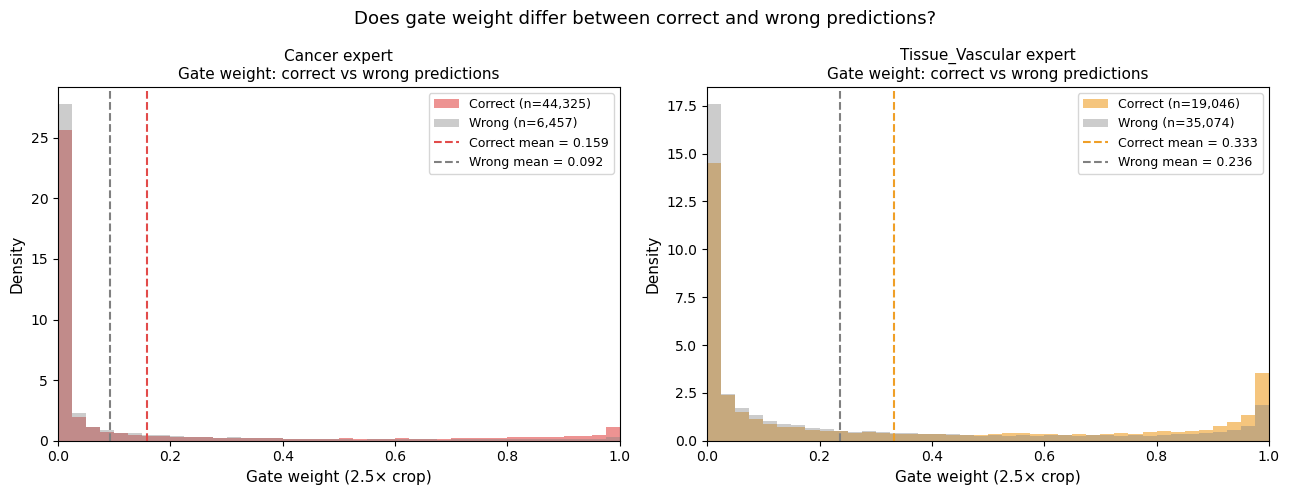

Saved: gate_correct_vs_wrong.png

Per-coarse mean gate weights (from predictions):
Coarse                mean 2.5x   mean 10x   std 2.5x
────────────────────────────────────────────────────
  Cancer                  0.150      0.850      0.288
  Lymphoid                0.214      0.786      0.290
  Neuroglial              0.462      0.538      0.422
  Stem_Progenitor         0.099      0.901      0.205
  Stromal                 0.294      0.706      0.246
  Tissue_Vascular         0.270      0.730      0.351
  OVERALL                 0.235      0.765      0.336


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PRED_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3/predictions.parquet"

FINE_TO_COARSE = {
    "Colon cancer cells": "Cancer", "Liver cancer cells": "Cancer",
    "Lung cancer cells": "Cancer", "Ovary cancer cells": "Cancer",
    "Pancreas cancer cells": "Cancer", "Skin cancer cells": "Cancer",
    "B cells": "Lymphoid", "NK cells": "Lymphoid", "T cells": "Lymphoid",
    "Astrocytes": "Neuroglial", "Microglia": "Neuroglial",
    "Neurons": "Neuroglial", "Oligodendrocytes": "Neuroglial",
    "Endothelial cells": "Tissue_Vascular", "Epithelial cells": "Tissue_Vascular",
    "Fibroblasts": "Tissue_Vascular", "Myeloid cells": "Tissue_Vascular",
    "Pericytes": "Tissue_Vascular", "Smooth muscle cells": "Tissue_Vascular",
    "Stem and progenitor cells": "Stem_Progenitor",
    "Stromal cells": "Stromal",
}

COARSE_ORDER = ["Cancer", "Lymphoid", "Neuroglial",
                "Stem_Progenitor", "Stromal", "Tissue_Vascular"]

COARSE_COLORS = {
    "Cancer": "#E24B4A", "Lymphoid": "#378ADD", "Neuroglial": "#1D9E75",
    "Tissue_Vascular": "#EF9F27", "Stem_Progenitor": "#7F77DD", "Stromal": "#888780",
}

# Expert-level gate weights from eval log
EXPERT_GATES = {
    "Router":           {"2.5x": 0.235, "10x": 0.765},
    "Cancer":           {"2.5x": 0.526, "10x": 0.474},
    "Lymphoid":         {"2.5x": 0.531, "10x": 0.469},
    "Neuroglial":       {"2.5x": 0.324, "10x": 0.676},
    "Tissue_Vascular":  {"2.5x": 0.362, "10x": 0.638},
}

df = pd.read_parquet(PRED_PATH)
df["coarse"] = df["label"].map(FINE_TO_COARSE)
all_fine_classes = sorted(df["label"].unique())
print(f"Loaded {len(df):,} cells")
print(f"Gate columns: gate_2_5x mean={df['gate_2_5x'].mean():.3f}, "
      f"gate_10x mean={df['gate_10x'].mean():.3f}")


# ═══════════════════════════════════════════════════════════════
# 1. Expert-level gate summary bar chart (from log)
# ═══════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 4))

experts   = list(EXPERT_GATES.keys())
vals_25x  = [EXPERT_GATES[e]["2.5x"] for e in experts]
vals_10x  = [EXPERT_GATES[e]["10x"]  for e in experts]
x = np.arange(len(experts))

bars1 = ax.bar(x - 0.2, vals_25x, 0.38, label="2.5× crop (tight nucleus)",
               color="#378ADD", alpha=0.85)
bars2 = ax.bar(x + 0.2, vals_10x, 0.38, label="10× crop (wider context)",
               color="#1D9E75", alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.0, alpha=0.6,
           label="Equal weight (0.5)")
ax.set_xticks(x)
ax.set_xticklabels(experts, fontsize=11)
ax.set_ylim(0, 0.95)
ax.set_ylabel("Learned Gate Weight", fontsize=12)
ax.set_title("Learned Scale Preference per Expert\n"
             "Gate weights: 2.5× (tight crop) vs 10× (wide context)",
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("gate_expert_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gate_expert_summary.png")


# ═══════════════════════════════════════════════════════════════
# 2. Per-fine-class gate weight distribution (violin plot)
# ═══════════════════════════════════════════════════════════════

# Sort classes by coarse group then by mean gate_2_5x
sorted_classes = []
for coarse in COARSE_ORDER:
    fines = [c for c in all_fine_classes if FINE_TO_COARSE.get(c) == coarse]
    fines_sorted = sorted(fines,
                          key=lambda c: df[df["label"] == c]["gate_2_5x"].mean())
    sorted_classes += fines_sorted

fig, ax = plt.subplots(figsize=(16, 6))

for pos, cls in enumerate(sorted_classes):
    coarse = FINE_TO_COARSE.get(cls, "DEFAULT")
    color  = COARSE_COLORS.get(coarse, "#888780")
    data   = df[df["label"] == cls]["gate_2_5x"].dropna().values

    if len(data) < 5:
        continue

    parts = ax.violinplot(data, positions=[pos], widths=0.7,
                          showmedians=True, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.65)
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.5)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.2, alpha=0.7,
           label="Equal weight (0.5)")
ax.axhline(df["gate_2_5x"].mean(), color="black", linestyle=":",
           linewidth=1.2, alpha=0.6,
           label=f"Overall mean 2.5× = {df['gate_2_5x'].mean():.3f}")

ax.set_xticks(range(len(sorted_classes)))
ax.set_xticklabels(sorted_classes, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Gate weight for 2.5× crop", fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title("Per-class gate weight distribution (2.5× crop)\n"
             "Sorted by coarse group, then by mean gate weight",
             fontsize=13)

# Coarse group separators
pos = 0
for coarse in COARSE_ORDER[:-1]:
    pos += sum(1 for c in sorted_classes if FINE_TO_COARSE.get(c) == coarse)
    ax.axvline(pos - 0.5, color="gray", linestyle="--",
               linewidth=0.8, alpha=0.5)

# Coarse color legend
handles = [plt.Rectangle((0,0), 1, 1, color=c, alpha=0.7)
           for c in COARSE_COLORS.values()]
ax.legend(handles + ax.get_legend_handles_labels()[0],
          list(COARSE_COLORS.keys()) + ax.get_legend_handles_labels()[1],
          fontsize=8, loc="upper left", ncol=2)

plt.tight_layout()
plt.savefig("gate_per_class_violin.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gate_per_class_violin.png")


# ═══════════════════════════════════════════════════════════════
# 3. Gate weight vs prediction correctness
# ═══════════════════════════════════════════════════════════════

df["correct"] = (df["label"] == df["pred_top1"]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, coarse in [
    (axes[0], "Cancer"),
    (axes[1], "Tissue_Vascular"),
]:
    sub     = df[df["coarse"] == coarse]
    correct = sub[sub["correct"] == 1]["gate_2_5x"].values
    wrong   = sub[sub["correct"] == 0]["gate_2_5x"].values
    color   = COARSE_COLORS[coarse]

    ax.hist(correct, bins=40, range=(0, 1), alpha=0.6, density=True,
            color=color, label=f"Correct (n={len(correct):,})")
    ax.hist(wrong,   bins=40, range=(0, 1), alpha=0.4, density=True,
            color="gray", label=f"Wrong (n={len(wrong):,})")

    ax.axvline(correct.mean(), color=color, linestyle="--", linewidth=1.5,
               label=f"Correct mean = {correct.mean():.3f}")
    ax.axvline(wrong.mean(),   color="gray",  linestyle="--", linewidth=1.5,
               label=f"Wrong mean = {wrong.mean():.3f}")

    ax.set_xlabel("Gate weight (2.5× crop)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"{coarse} expert\nGate weight: correct vs wrong predictions",
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)

plt.suptitle("Does gate weight differ between correct and wrong predictions?",
             fontsize=13)
plt.tight_layout()
plt.savefig("gate_correct_vs_wrong.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gate_correct_vs_wrong.png")


# ═══════════════════════════════════════════════════════════════
# 4. Per-coarse mean gate weights (from predictions.parquet)
# ═══════════════════════════════════════════════════════════════

print("\nPer-coarse mean gate weights (from predictions):")
print(f"{'Coarse':<20} {'mean 2.5x':>10} {'mean 10x':>10} {'std 2.5x':>10}")
print("─" * 52)
for coarse in COARSE_ORDER:
    sub = df[df["coarse"] == coarse]["gate_2_5x"].dropna()
    print(f"  {coarse:<18} {sub.mean():>10.3f} {1-sub.mean():>10.3f} {sub.std():>10.3f}")

overall = df["gate_2_5x"].dropna()
print(f"  {'OVERALL':<18} {overall.mean():>10.3f} {1-overall.mean():>10.3f} {overall.std():>10.3f}")

## gate 检查

Router gate distribution:
  mean:  0.2347
  std:   0.3357
  min:   0.0000
  max:   1.0000
  % < 0.1 (collapsed to 10x): 59.2%
  % > 0.9 (collapsed to 2.5x): 10.1%
  % in [0.3, 0.7] (balanced): 11.2%

Per-coarse router gate (2.5x):
                   mean     std
coarse                         
Cancer           0.1502  0.2876
Lymphoid         0.2144  0.2903
Neuroglial       0.4617  0.4224
Stem_Progenitor  0.0991  0.2050
Stromal          0.2936  0.2461
Tissue_Vascular  0.2701  0.3513


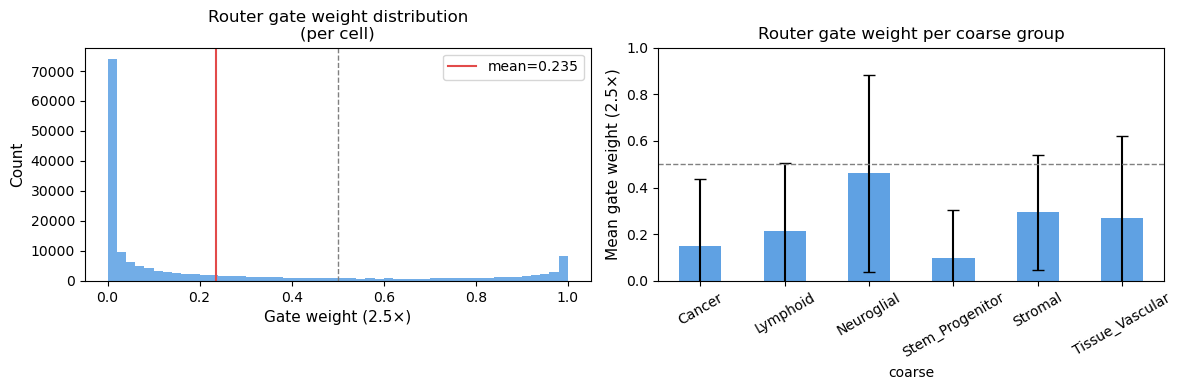


Per-fine-class router gate (2.5x)
  Class                               Coarse               mean    std   %<0.1   %>0.9
  ─────────────────────────────────────────────────────────────────────────
  ─────────────────────────────────────────────────────────────────────────
  Colon cancer cells                  Cancer              0.253  0.371   63.1%   14.9%
  Liver cancer cells                  Cancer              0.074  0.175   83.8%    1.4%
  Lung cancer cells                   Cancer              0.248  0.345   60.4%    7.7%
  Ovary cancer cells                  Cancer              0.007  0.049   98.5%    0.1%
  Pancreas cancer cells               Cancer              0.078  0.180   82.5%    1.0%
  Skin cancer cells                   Cancer              0.173  0.282   67.0%    4.1%
  ─────────────────────────────────────────────────────────────────────────
  B cells                             Lymphoid            0.183  0.271   60.7%    4.5%
  NK cells                            Lym

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
PRED_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3/predictions.parquet"
df = pd.read_parquet(PRED_PATH)

print("Router gate distribution:")
print(f"  mean:  {df['gate_2_5x'].mean():.4f}")
print(f"  std:   {df['gate_2_5x'].std():.4f}")
print(f"  min:   {df['gate_2_5x'].min():.4f}")
print(f"  max:   {df['gate_2_5x'].max():.4f}")
print(f"  % < 0.1 (collapsed to 10x): {(df['gate_2_5x'] < 0.1).mean()*100:.1f}%")
print(f"  % > 0.9 (collapsed to 2.5x): {(df['gate_2_5x'] > 0.9).mean()*100:.1f}%")
print(f"  % in [0.3, 0.7] (balanced): {((df['gate_2_5x'] > 0.3) & (df['gate_2_5x'] < 0.7)).mean()*100:.1f}%")

# 画分布图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Router gate distribution
axes[0].hist(df["gate_2_5x"], bins=50, color="#378ADD", alpha=0.7)
axes[0].axvline(0.5, color="gray", linestyle="--", linewidth=1.0)
axes[0].axvline(df["gate_2_5x"].mean(), color="#E24B4A", linestyle="-",
                linewidth=1.5, label=f"mean={df['gate_2_5x'].mean():.3f}")
axes[0].set_xlabel("Gate weight (2.5×)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Router gate weight distribution\n(per cell)", fontsize=12)
axes[0].legend()

# Per-coarse breakdown
FINE_TO_COARSE = {
    "Colon cancer cells": "Cancer", "Liver cancer cells": "Cancer",
    "Lung cancer cells": "Cancer", "Ovary cancer cells": "Cancer",
    "Pancreas cancer cells": "Cancer", "Skin cancer cells": "Cancer",
    "B cells": "Lymphoid", "NK cells": "Lymphoid", "T cells": "Lymphoid",
    "Astrocytes": "Neuroglial", "Microglia": "Neuroglial",
    "Neurons": "Neuroglial", "Oligodendrocytes": "Neuroglial",
    "Endothelial cells": "Tissue_Vascular", "Epithelial cells": "Tissue_Vascular",
    "Fibroblasts": "Tissue_Vascular", "Myeloid cells": "Tissue_Vascular",
    "Pericytes": "Tissue_Vascular", "Smooth muscle cells": "Tissue_Vascular",
    "Stem and progenitor cells": "Stem_Progenitor",
    "Stromal cells": "Stromal",
}
df["coarse"] = df["label"].map(FINE_TO_COARSE)

coarse_means = df.groupby("coarse")["gate_2_5x"].agg(["mean", "std"])
print("\nPer-coarse router gate (2.5x):")
print(coarse_means.round(4))

coarse_means["mean"].plot(kind="bar", ax=axes[1],
                           color="#378ADD", alpha=0.8, yerr=coarse_means["std"],
                           capsize=4)
axes[1].axhline(0.5, color="gray", linestyle="--", linewidth=1.0)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Mean gate weight (2.5×)", fontsize=11)
axes[1].set_title("Router gate weight per coarse group", fontsize=12)
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"\n{'='*75}")
print(f"Per-fine-class router gate (2.5x)")
print(f"{'='*75}")
print(f"  {'Class':<35} {'Coarse':<18} {'mean':>6} {'std':>6} {'%<0.1':>7} {'%>0.9':>7}")
print(f"  {'─'*73}")

prev_coarse = None
for coarse in COARSE_ORDER:
    fines = [c for c in sorted(df["label"].unique()) 
             if FINE_TO_COARSE.get(c) == coarse]
    for cls in fines:
        if coarse != prev_coarse:
            print(f"  {'─'*73}")
            prev_coarse = coarse
        sub = df[df["label"] == cls]["gate_2_5x"]
        print(f"  {cls:<35} {coarse:<18} "
              f"{sub.mean():>6.3f} {sub.std():>6.3f} "
              f"{(sub<0.1).mean()*100:>6.1f}% "
              f"{(sub>0.9).mean()*100:>6.1f}%")

print(f"  {'─'*73}")
overall = df["gate_2_5x"]
print(f"  {'OVERALL':<35} {'':18} "
      f"{overall.mean():>6.3f} {overall.std():>6.3f} "
      f"{(overall<0.1).mean()*100:>6.1f}% "
      f"{(overall>0.9).mean()*100:>6.1f}%")